# Importing

In [1]:
import os
print("Current working dir:", os.getcwd())

import sys
import os

root_dir = os.path.abspath("..")
print("Adding to sys.path:", root_dir)
sys.path.insert(0, root_dir)  # Insert ensures priority

import importlib.util

api_path = os.path.join(root_dir, "LCBench", "api.py")
spec = importlib.util.spec_from_file_location("LCBench.api", api_path)
print(spec)
api = importlib.util.module_from_spec(spec)
spec.loader.exec_module(api)

Benchmark = api.Benchmark

os.makedirs("../LCBench/cached", exist_ok=True)
bench_dir = "../LCBench/cached/data_2k.json"
bench = Benchmark(bench_dir, cache=False)

Current working dir: /accounts/projects/jordan/tcai/CostAwareStopping/notebooks
Adding to sys.path: /accounts/projects/jordan/tcai/CostAwareStopping
ModuleSpec(name='LCBench.api', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7fec02621190>, origin='/accounts/projects/jordan/tcai/CostAwareStopping/LCBench/api.py')
==> Loading data...
==> No cached data found or cache set to False.
==> Reading json data...
==> Done.


# API exploration

### Queryable tags

Tags starting with "Train/" indicate metrics which are logged every epoch.

In [ ]:
from pprint import pprint
queriable_tags = bench.get_queriable_tags()
pprint(queriable_tags)

### Datasets

In [2]:
dataset_names = bench.get_dataset_names()
openml_task_ids = bench.get_openml_task_ids()

print(dataset_names)
print(openml_task_ids)

['APSFailure', 'Amazon_employee_access', 'Australian', 'Fashion-MNIST', 'KDDCup09_appetency', 'MiniBooNE', 'adult', 'airlines', 'albert', 'bank-marketing', 'blood-transfusion-service-center', 'car', 'christine', 'cnae-9', 'connect-4', 'covertype', 'credit-g', 'dionis', 'fabert', 'helena', 'higgs', 'jannis', 'jasmine', 'jungle_chess_2pcs_raw_endgame_complete', 'kc1', 'kr-vs-kp', 'mfeat-factors', 'nomao', 'numerai28.6', 'phoneme', 'segment', 'shuttle', 'sylvine', 'vehicle', 'volkert']
[168868, 34539, 167104, 189908, 3945, 168335, 126025, 189354, 189866, 126029, 167184, 189905, 168908, 167185, 167201, 7593, 167161, 189873, 168910, 168329, 167200, 168330, 189862, 189909, 167181, 167149, 167152, 126026, 167083, 167190, 189906, 146212, 189865, 167168, 168331]


### Querying

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams["font.sans-serif"] = "Liberation Sans"


In [3]:
bench.query(dataset_name="vehicle", tag="features", config_id=1999)

18

In [ ]:
bench.query(dataset_name="Fashion-MNIST", tag="classes", config_id=1999)

10

In [4]:
dataset_names = ['APSFailure', 'Amazon_employee_access', 'Australian', 'Fashion-MNIST', 'KDDCup09_appetency', 'MiniBooNE', 'adult', 'airlines', 'albert', 'bank-marketing', 'blood-transfusion-service-center', 'car', 'christine', 'cnae-9', 'connect-4', 'covertype', 'credit-g', 'dionis', 'fabert', 'helena', 'higgs', 'jannis', 'jasmine', 'jungle_chess_2pcs_raw_endgame_complete', 'kc1', 'kr-vs-kp', 'mfeat-factors', 'nomao', 'numerai28.6', 'phoneme', 'segment', 'shuttle', 'sylvine', 'vehicle', 'volkert']
best_acc = {}
for d in dataset_names:
    best_acc[d] = bench.query_best_final(d, "final_test_accuracy", "final_test_accuracy", 0)

print(best_acc)

{'APSFailure': 98.9274322169059, 'Amazon_employee_access': 94.22970223783985, 'Australian': 86.34361233480176, 'Fashion-MNIST': 90.17316017316017, 'KDDCup09_appetency': 98.21818181818182, 'MiniBooNE': 90.20315921904852, 'adult': 83.00552211950115, 'airlines': 63.185896391512216, 'albert': 66.32342566397537, 'bank-marketing': 89.32904350157517, 'blood-transfusion-service-center': 84.14634146341463, 'car': 93.85964912280701, 'christine': 72.76286353467562, 'cnae-9': 95.2247191011236, 'connect-4': 74.46732158076527, 'covertype': 77.46252620818426, 'credit-g': 77.57575757575758, 'dionis': 87.8085363545019, 'fabert': 65.83302684810593, 'helena': 28.352312340227748, 'higgs': 71.86302385956238, 'jannis': 67.02012159814707, 'jasmine': 77.7439024390244, 'jungle_chess_2pcs_raw_endgame_complete': 85.04394861392834, 'kc1': 86.90647482014388, 'kr-vs-kp': 98.10246679316889, 'mfeat-factors': 98.63636363636363, 'nomao': 95.9113690319177, 'numerai28.6': 52.68837501966336, 'phoneme': 80.98710039259674, 

In [ ]:
bench.get_queriable_tags()

In [10]:
bench.query(dataset_name="Fashion-MNIST", tag="config", config_id=1999)

{'batch_size': 57,
 'imputation_strategy': 'mean',
 'learning_rate_scheduler': 'cosine_annealing',
 'loss': 'cross_entropy_weighted',
 'network': 'shapedmlpnet',
 'max_dropout': 0.404549055549585,
 'normalization_strategy': 'standardize',
 'optimizer': 'sgd',
 'cosine_annealing_T_max': 50,
 'cosine_annealing_eta_min': 1e-08,
 'activation': 'relu',
 'max_units': 408,
 'mlp_shape': 'funnel',
 'num_layers': 4,
 'learning_rate': 0.09369657122908694,
 'momentum': 0.28168216579061095,
 'weight_decay': 0.05218621267283741}

In [5]:
best_acc = bench.query_best_final("Fashion-MNIST", "final_test_accuracy", "final_test_accuracy")
best_acc, 0.5*0.01*(100-best_acc)

(90.17316017316017, 0.04913419913419915)

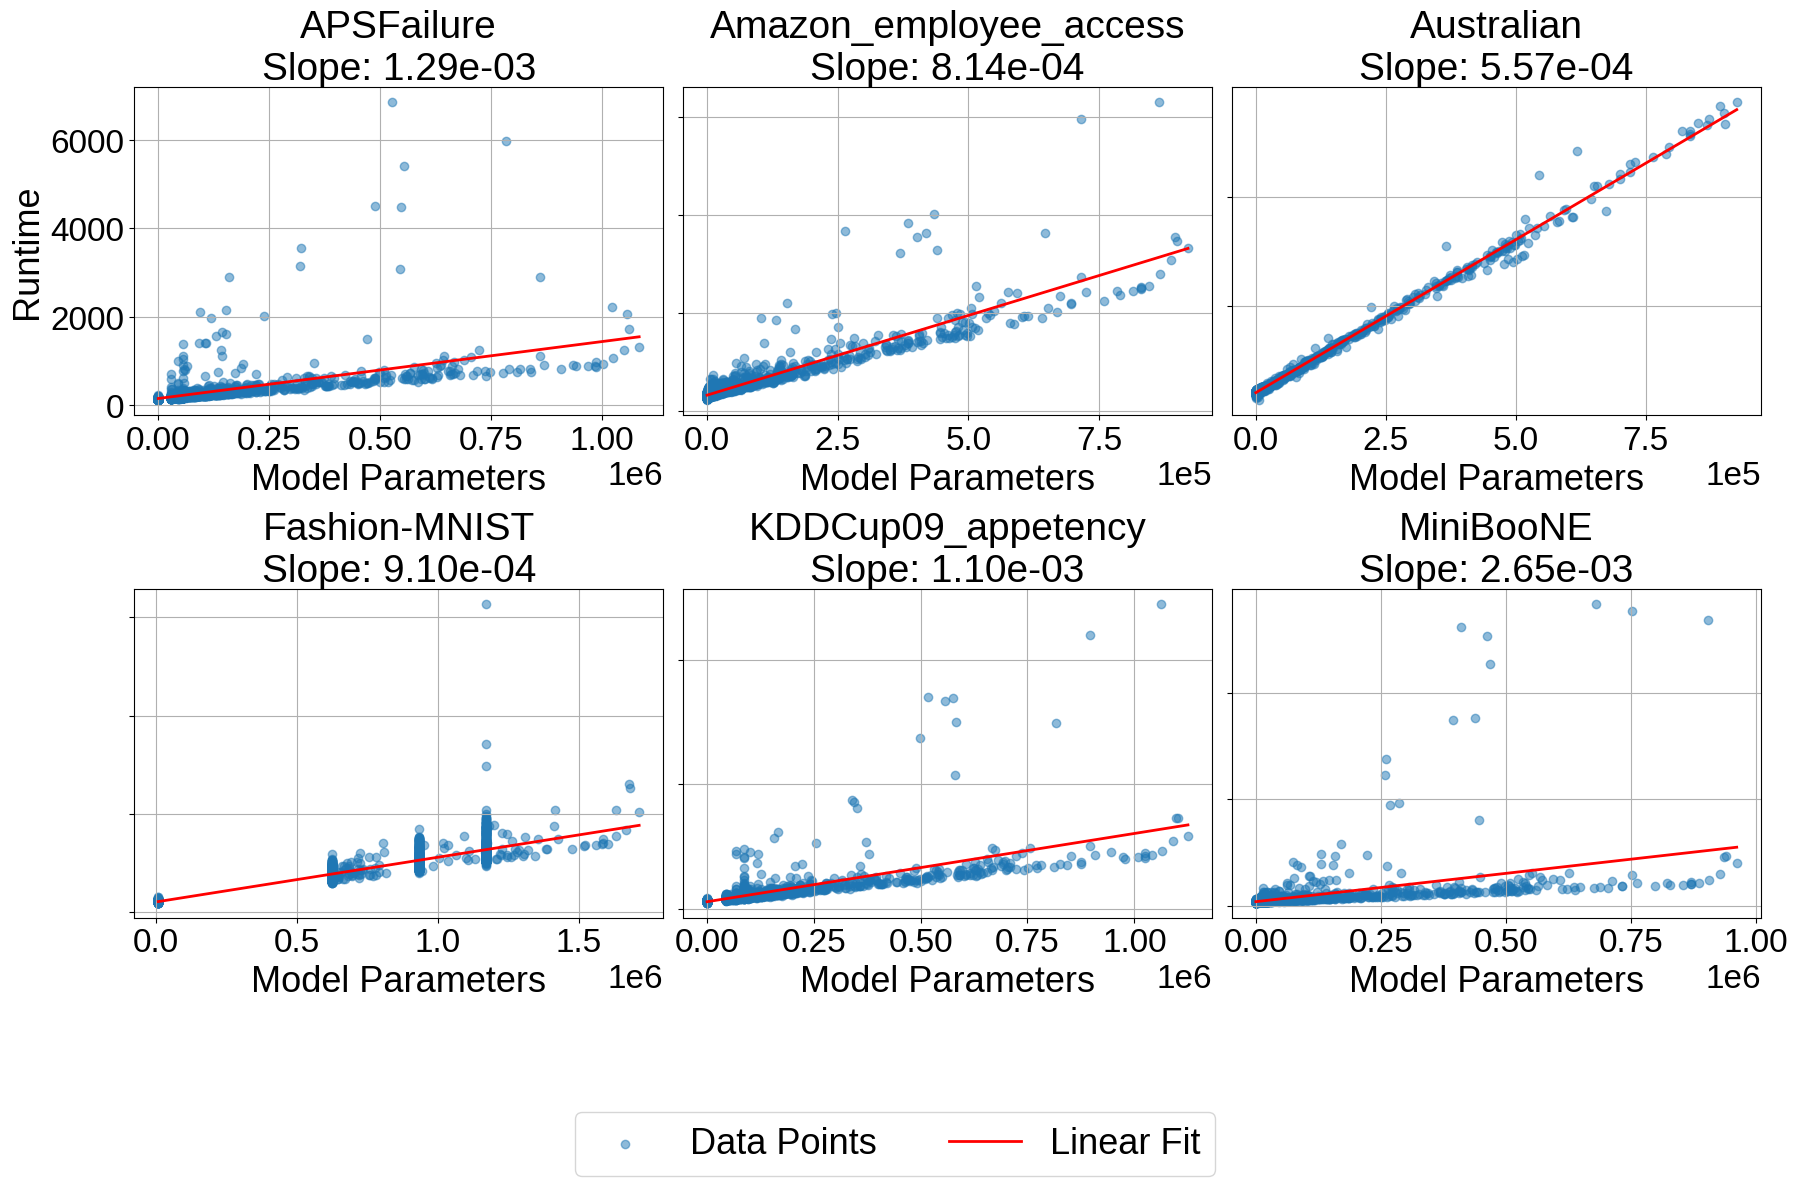

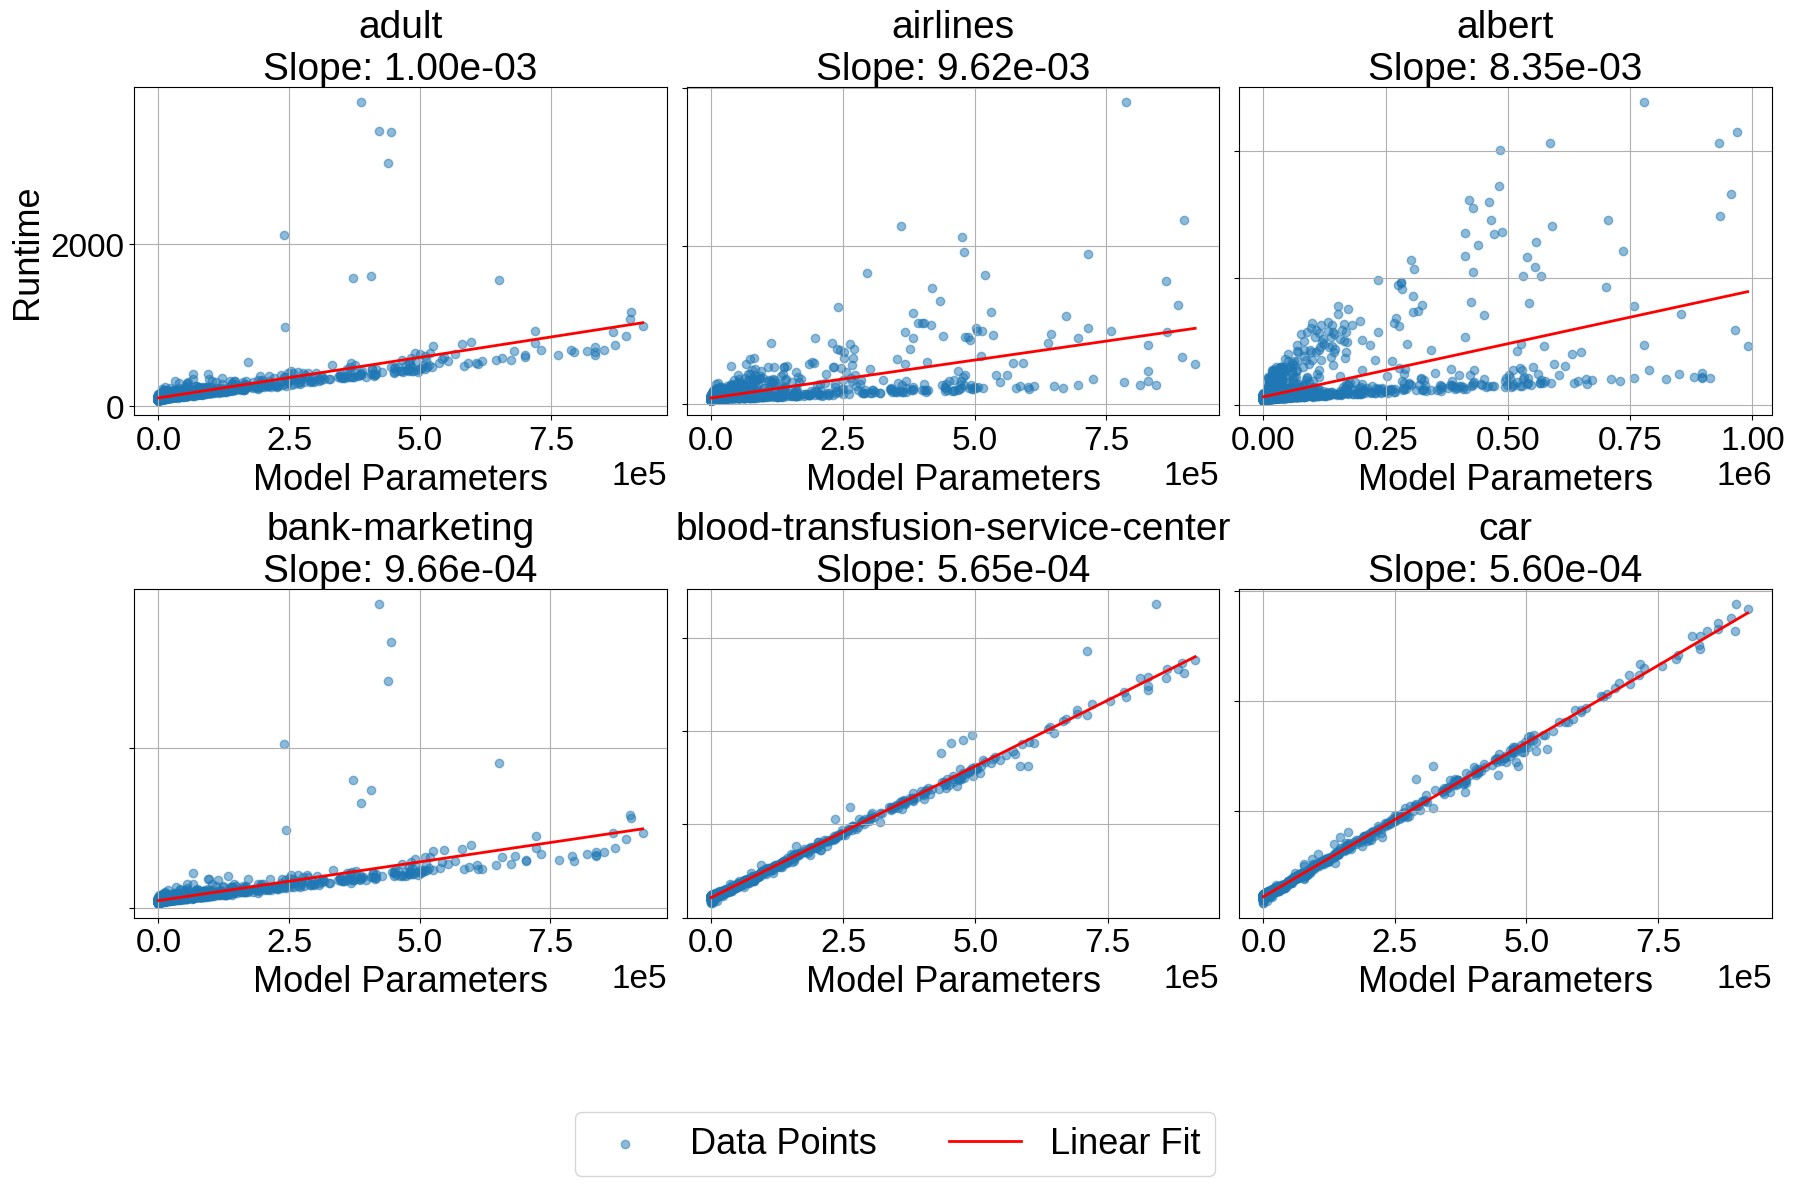

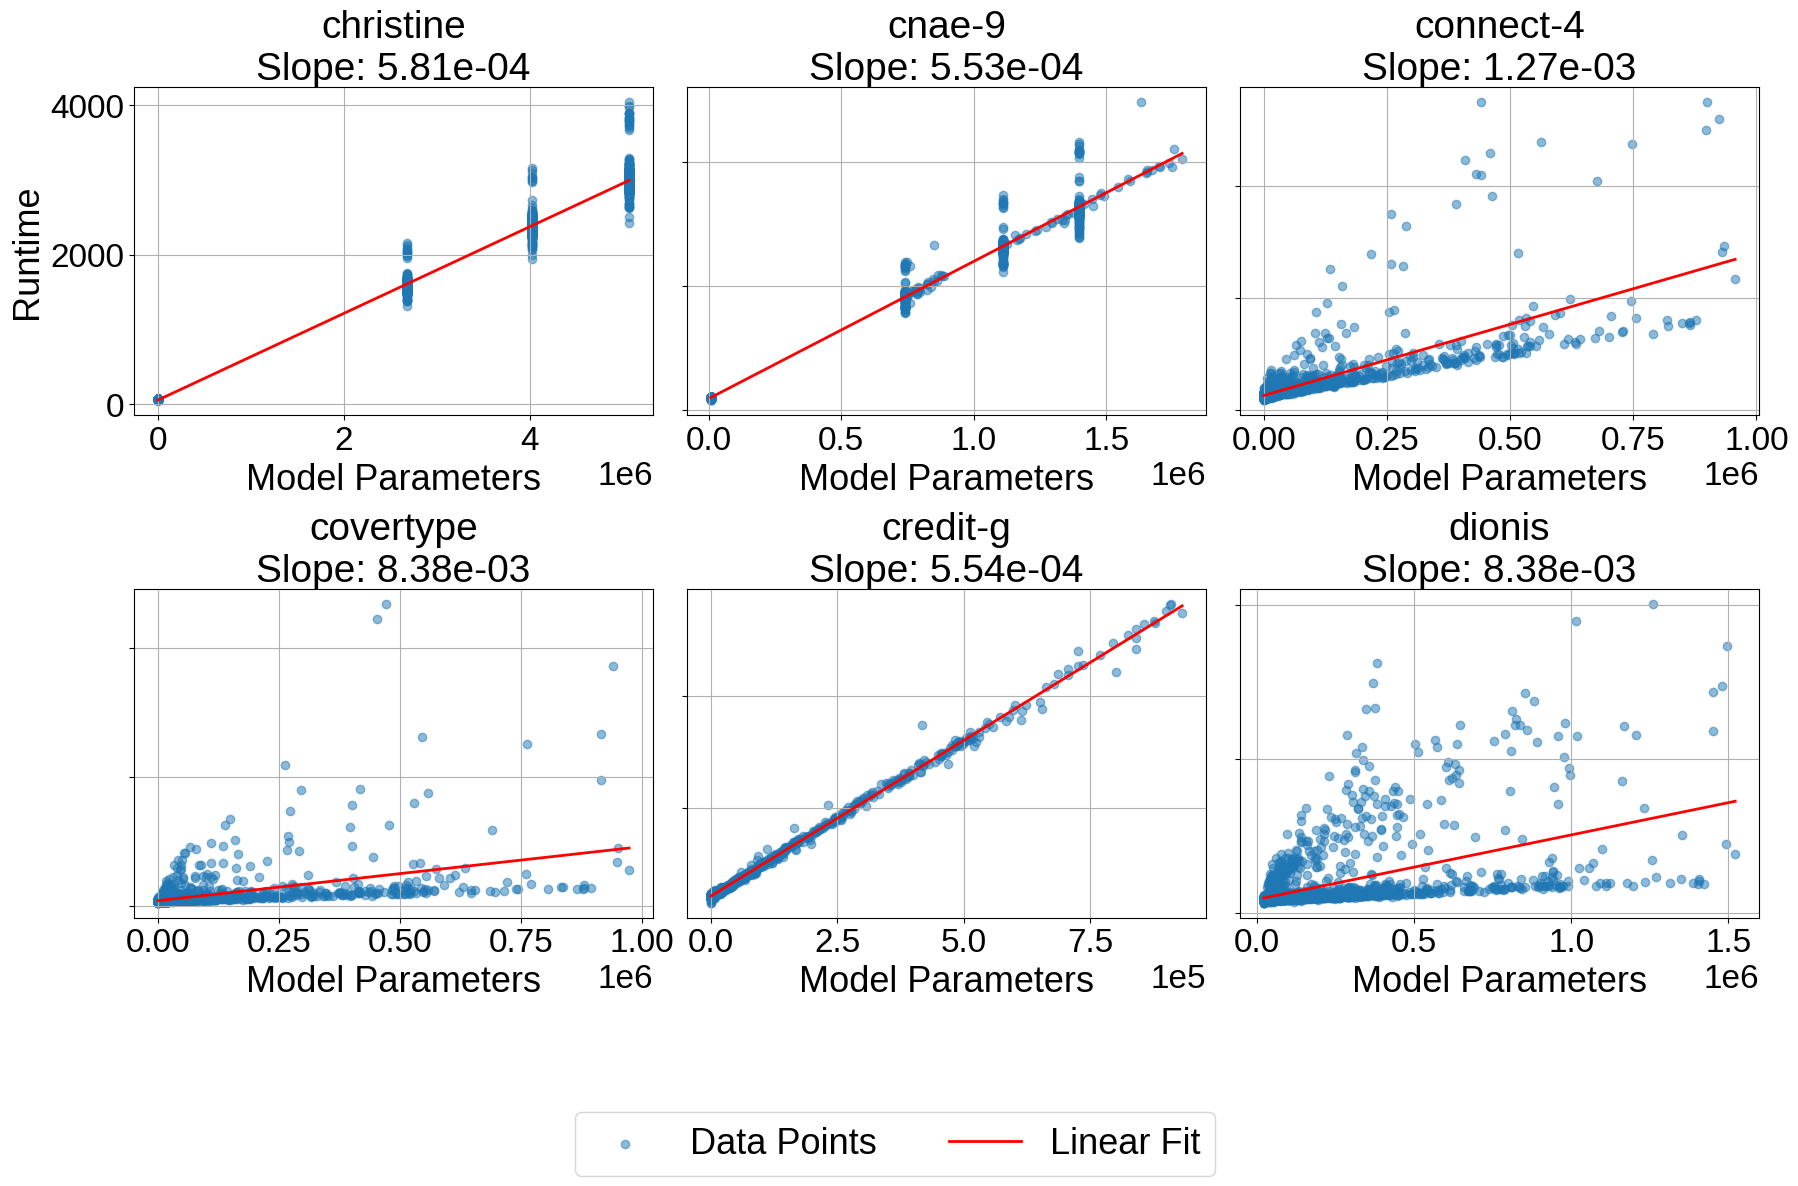

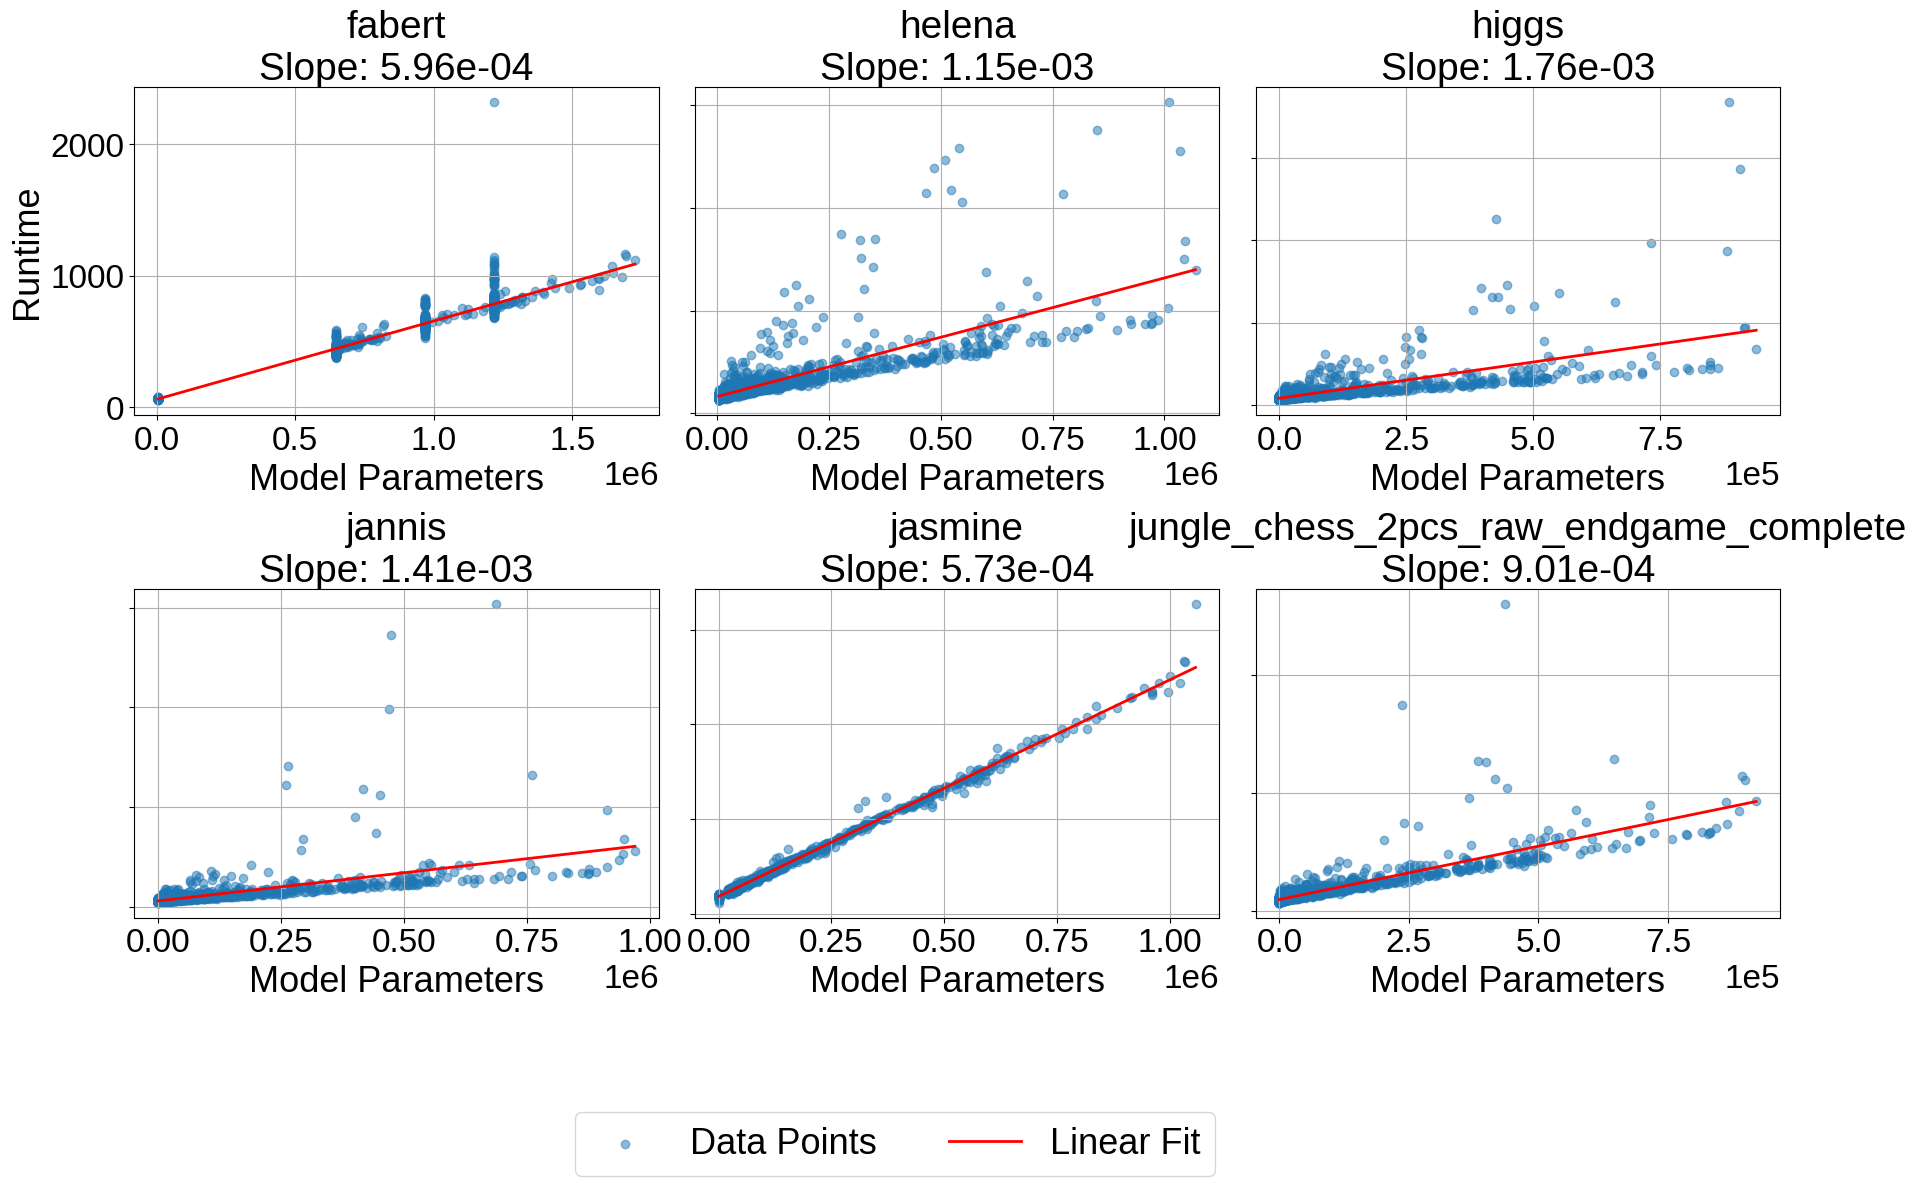

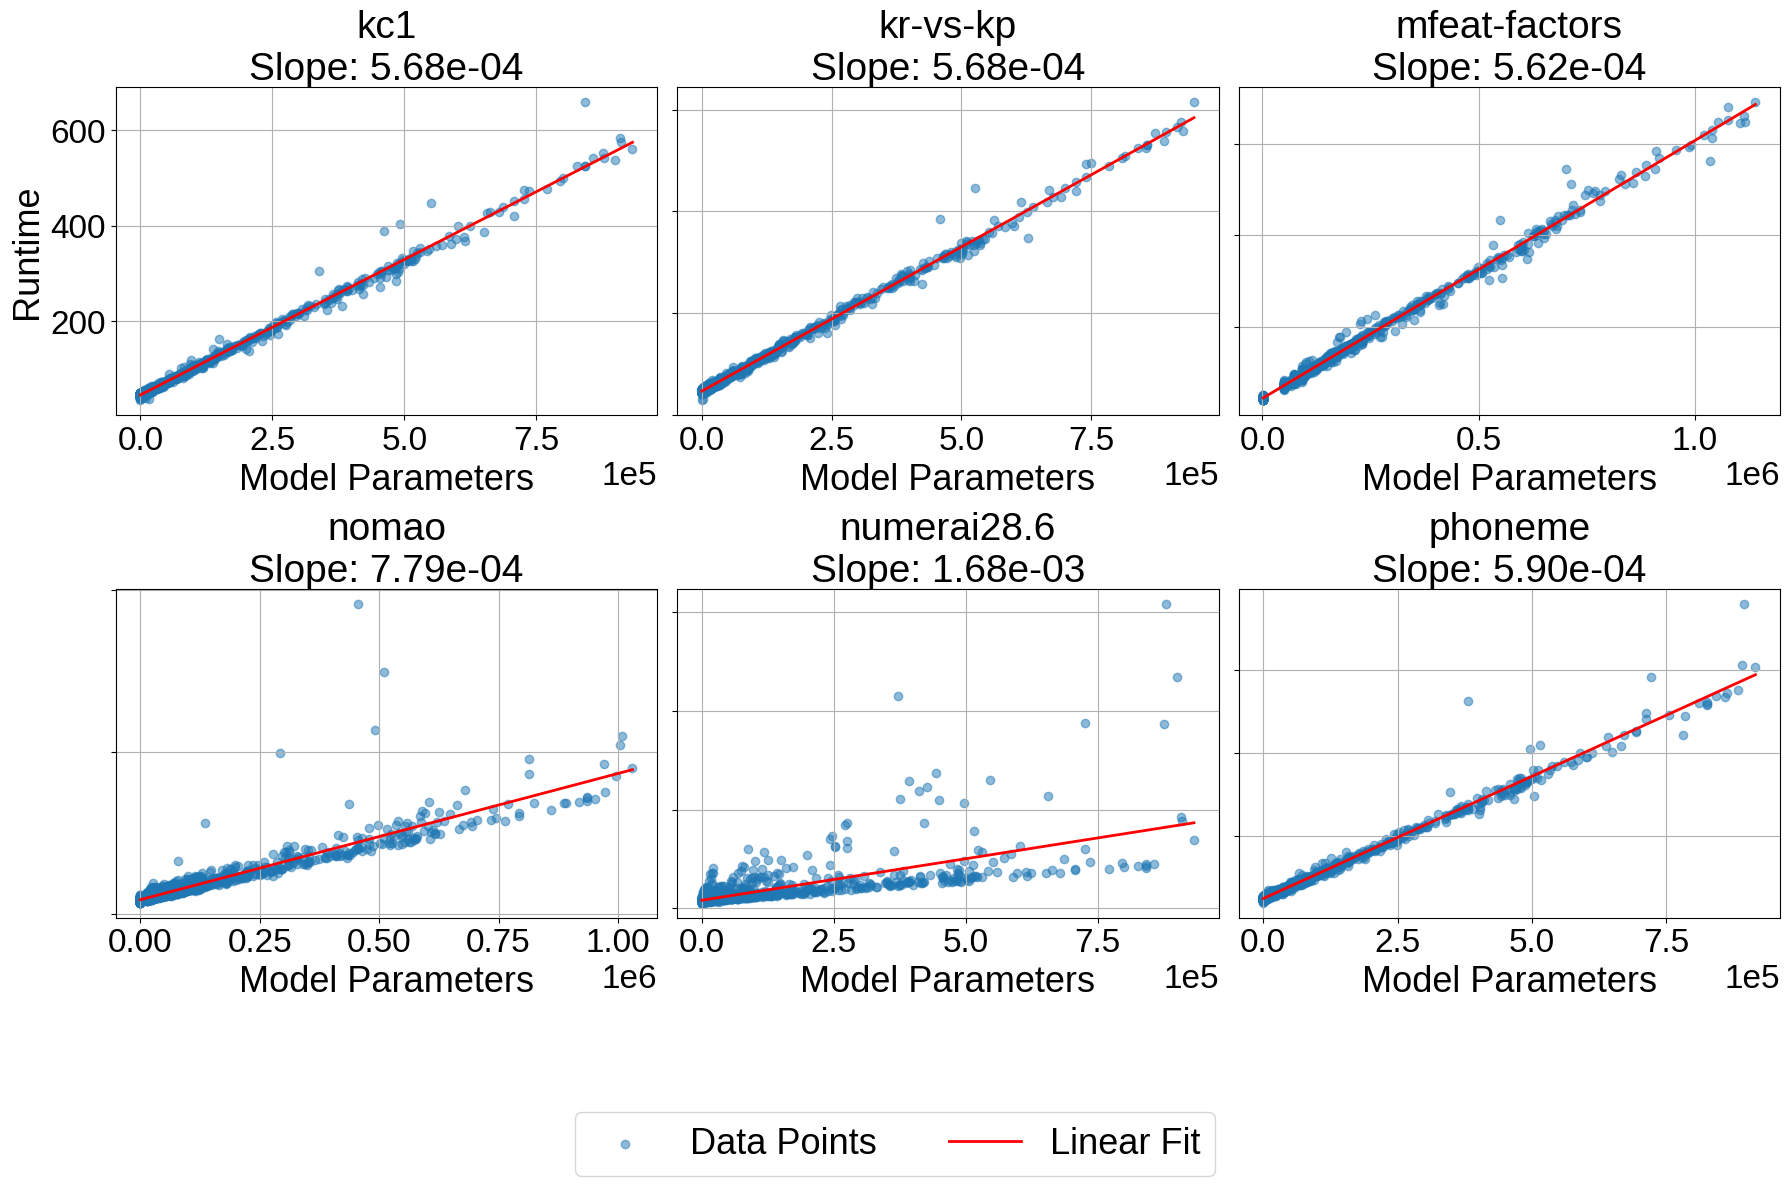

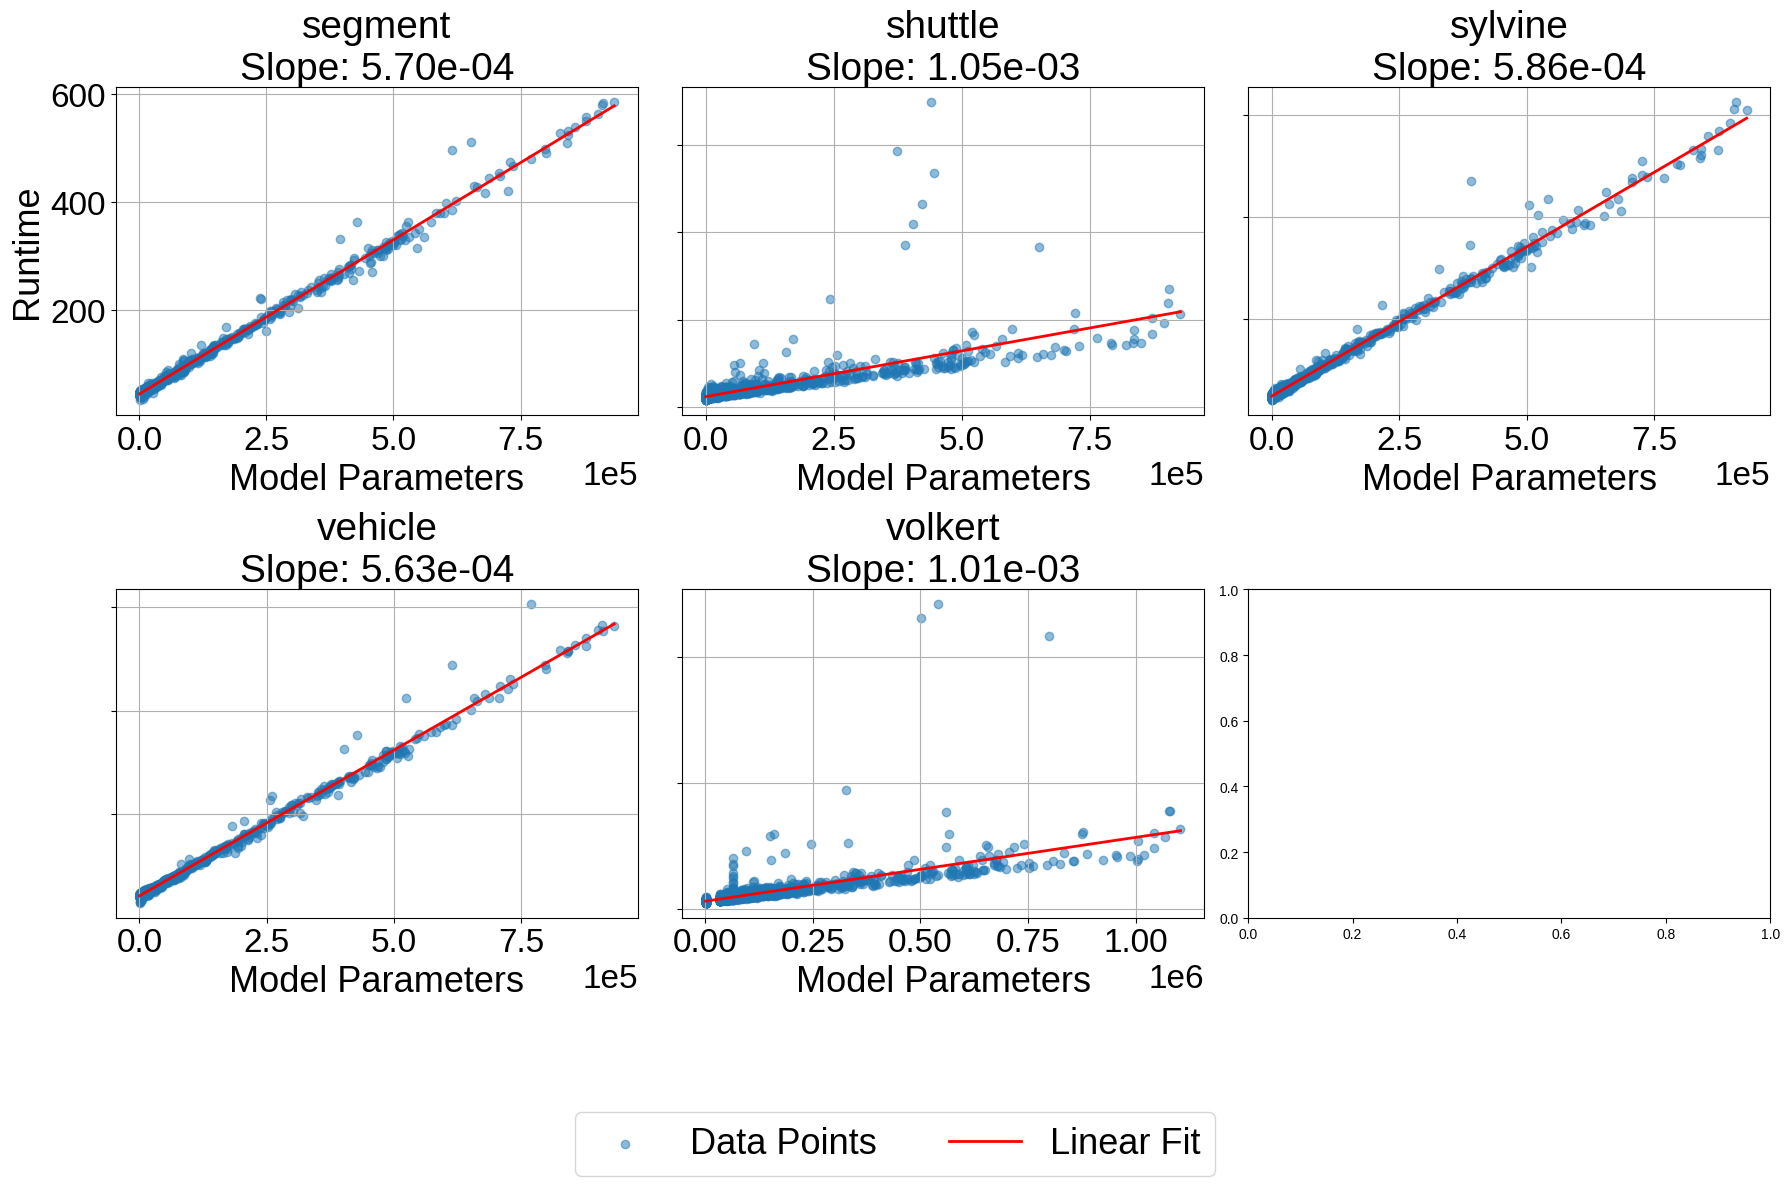

In [8]:
import numpy as np
import math
import os 

dataset_names = ['APSFailure', 'Amazon_employee_access', 'Australian', 'Fashion-MNIST', 'KDDCup09_appetency', 'MiniBooNE', 'adult', 'airlines', 'albert', 'bank-marketing', 'blood-transfusion-service-center', 'car', 'christine', 'cnae-9', 'connect-4', 'covertype', 'credit-g', 'dionis', 'fabert', 'helena', 'higgs', 'jannis', 'jasmine', 'jungle_chess_2pcs_raw_endgame_complete', 'kc1', 'kr-vs-kp', 'mfeat-factors', 'nomao', 'numerai28.6', 'phoneme', 'segment', 'shuttle', 'sylvine', 'vehicle', 'volkert']
 # Assumes there are exactly six datasets
num_configs = 2000  # Adjust based on available configurations
slope_dict = {}
# Create a 1x3 grid of subplots for each dataset.
num_plots = math.ceil(len(dataset_names) / 6)
for plot_idx in range(num_plots):
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for i, (ax, dataset) in enumerate(zip(axes, dataset_names[plot_idx*6:(plot_idx+1)*6])):
        model_params_list = []  # Number of model parameters for each configuration
        time_vals = []          # Corresponding time (using the last time stamp)
        
        # Collect data
        for config_id in range(num_configs):
            try:
                params = bench.query(dataset_name=dataset, tag="model_parameters", config_id=config_id)
                time_val = bench.query(dataset_name=dataset, tag="time", config_id=config_id)[-1]
                model_params_list.append(params)
                time_vals.append(time_val)
            except Exception as e:
                print(f"Skipping config {config_id} for dataset {dataset}: {e}")
                continue
        
        ax.scatter(model_params_list, time_vals, alpha=0.5, label='Data Points')
        
        if len(model_params_list) > 1:
            # Fit linear regression
            coefficients = np.polyfit(model_params_list, time_vals, 1)
            slope, intercept = coefficients
            line_fit = np.poly1d(coefficients)
            
            # Plot the line
            x_range = np.linspace(min(model_params_list), max(model_params_list), 100)
            ax.plot(x_range, line_fit(x_range), color="red", linewidth=2, label='Linear Fit')
            
            # Print and display slope
            # print(f"Slope for {dataset}: {slope:.4f}")
            slope_dict[dataset] = slope
            ax.set_title(f"{dataset}\nSlope: {slope:.2e}", fontsize=28)
        else:
            ax.set_title(f"{dataset}\nInsufficient data", fontsize=28)

        if i == 0:
            ax.set_ylabel("Runtime", fontsize=26)
        else:
            ax.set_ylabel("")
            ax.tick_params(labelleft=False)
        ax.set_xlabel("Model Parameters", fontsize=26)
        ax.tick_params(axis='both', labelsize=24)
        ax.grid(True)
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
        ax.xaxis.get_offset_text().set_fontsize(24)

    # plt.suptitle("Time vs Model Parameters with Linear Regression and Slopes", fontsize=)
    # Get legend handles and labels from one of the axes
    handles, labels = axes[0].get_legend_handles_labels()

    # Place the legend below all subplots
    fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=26, bbox_to_anchor=(0.5, -0.05))
    plt.tight_layout(rect=[0, 0.1, 1, 0.95])
    os.makedirs("../plots/lcbench_full_runtime_proxy", exist_ok=True)
    plt.savefig(f"../plots/lcbench_full_runtime_proxy/runtime_proxy_{plot_idx}.pdf")

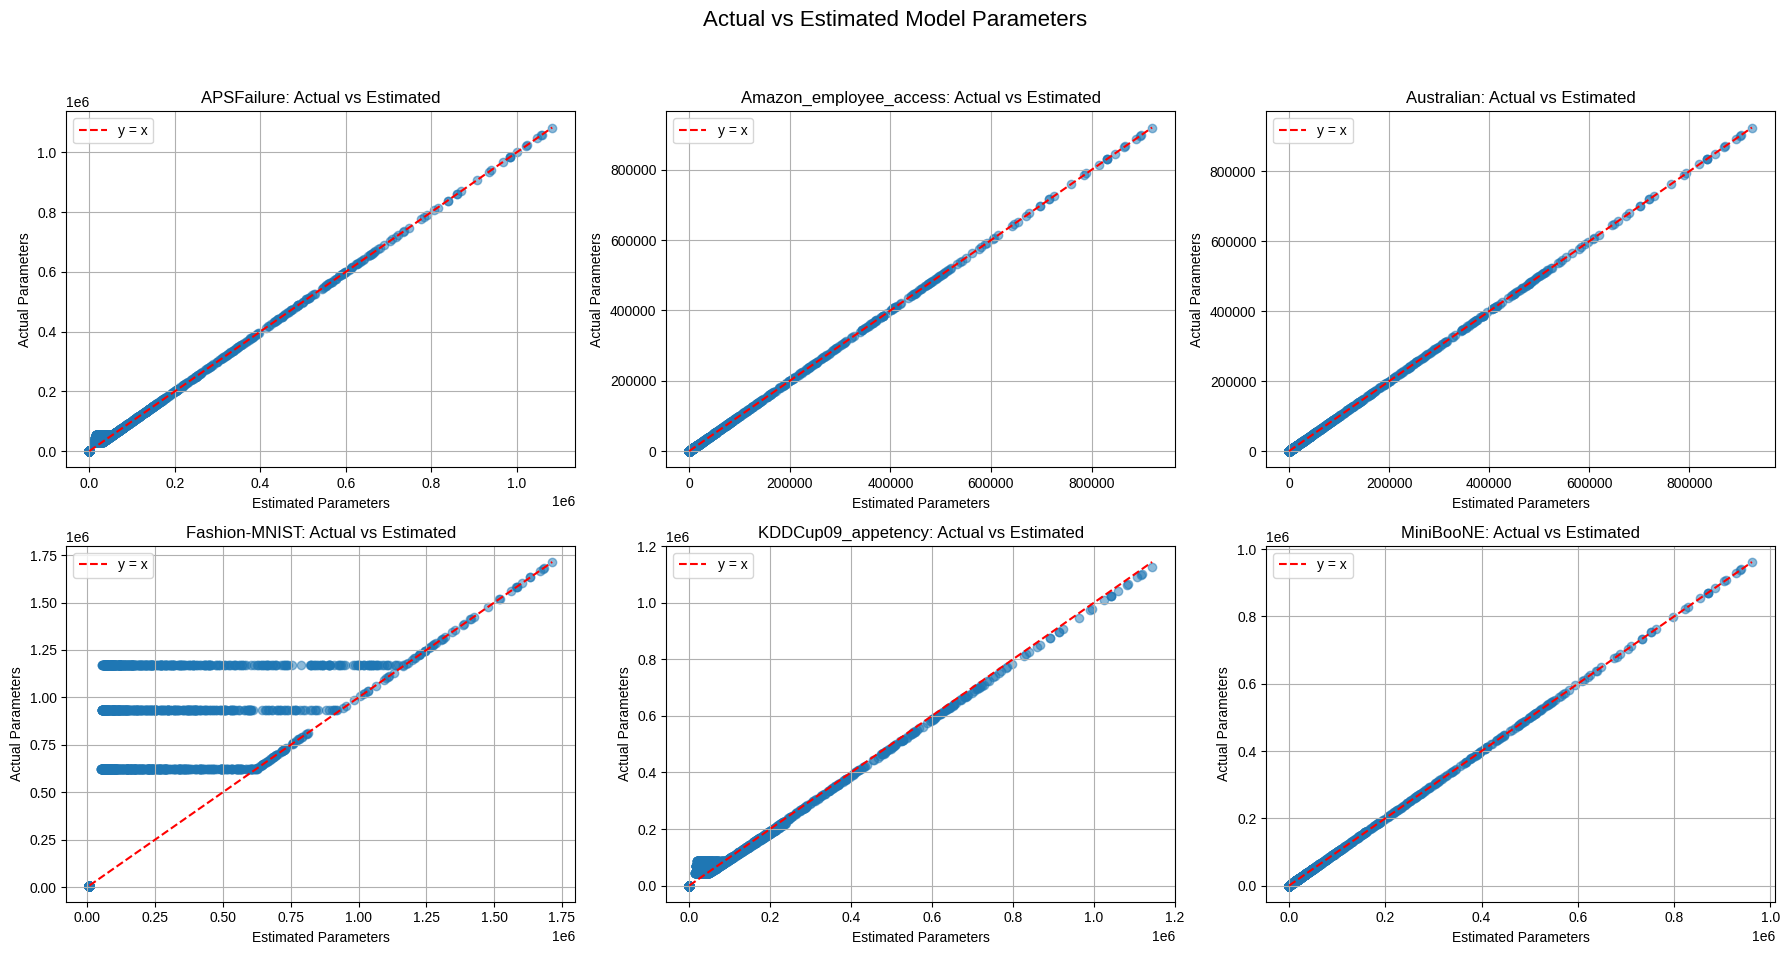

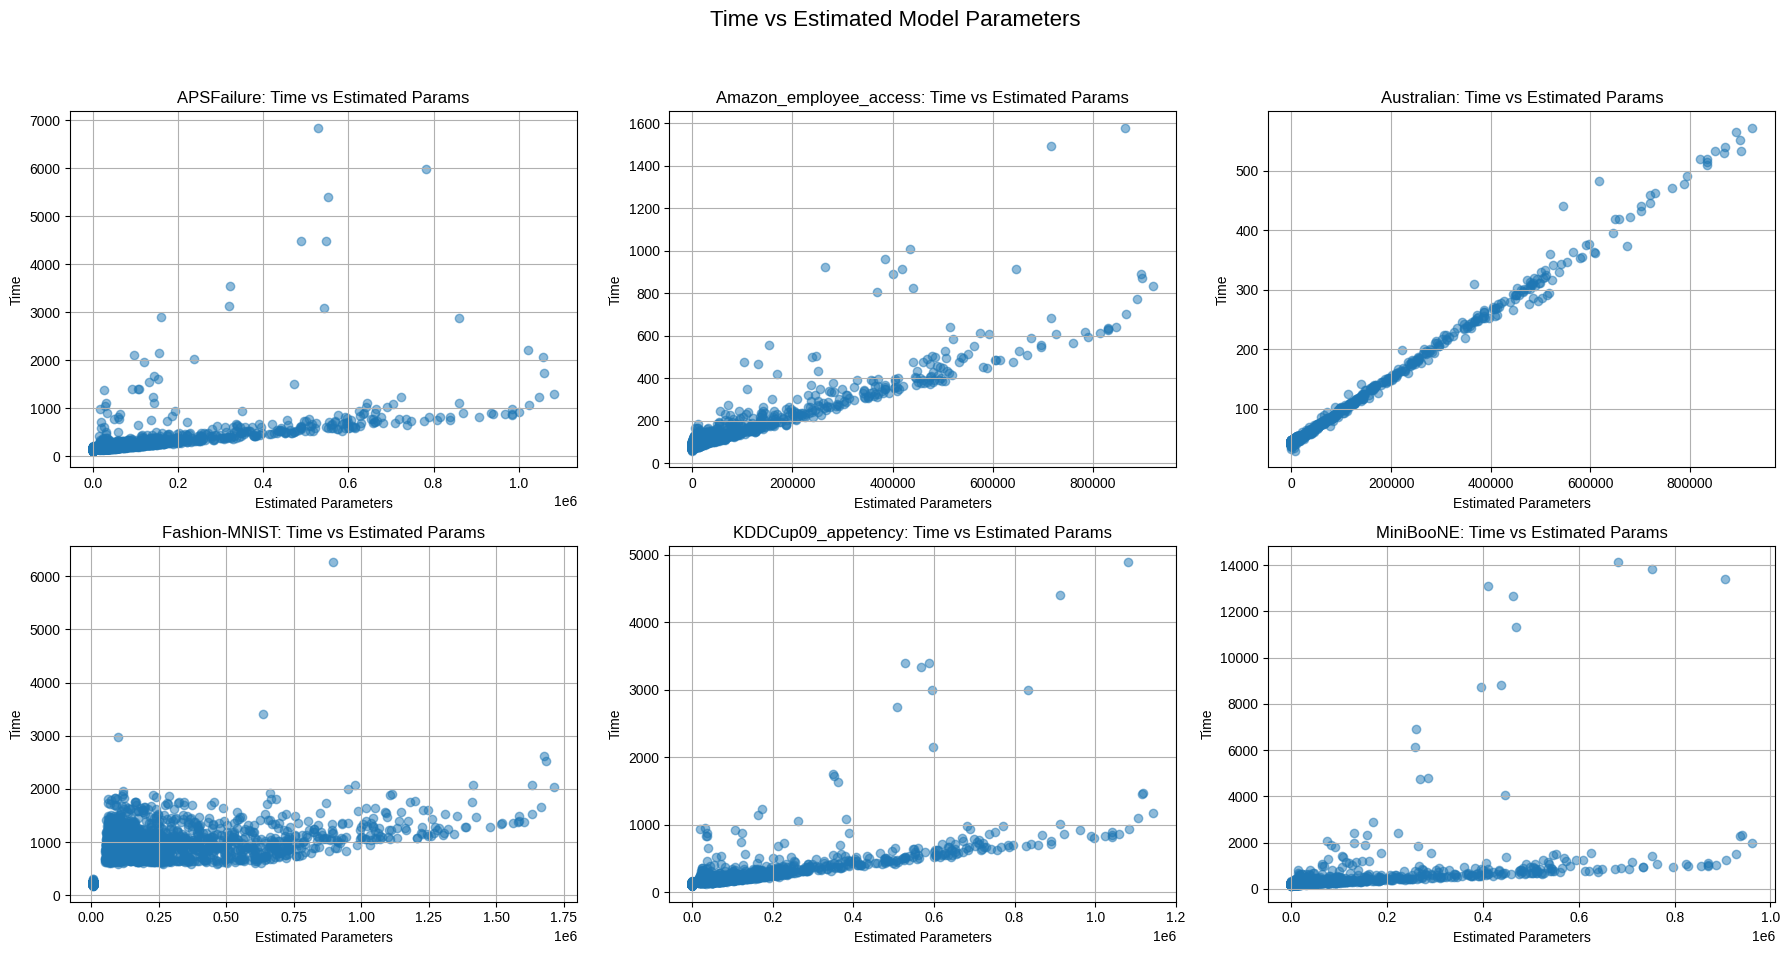

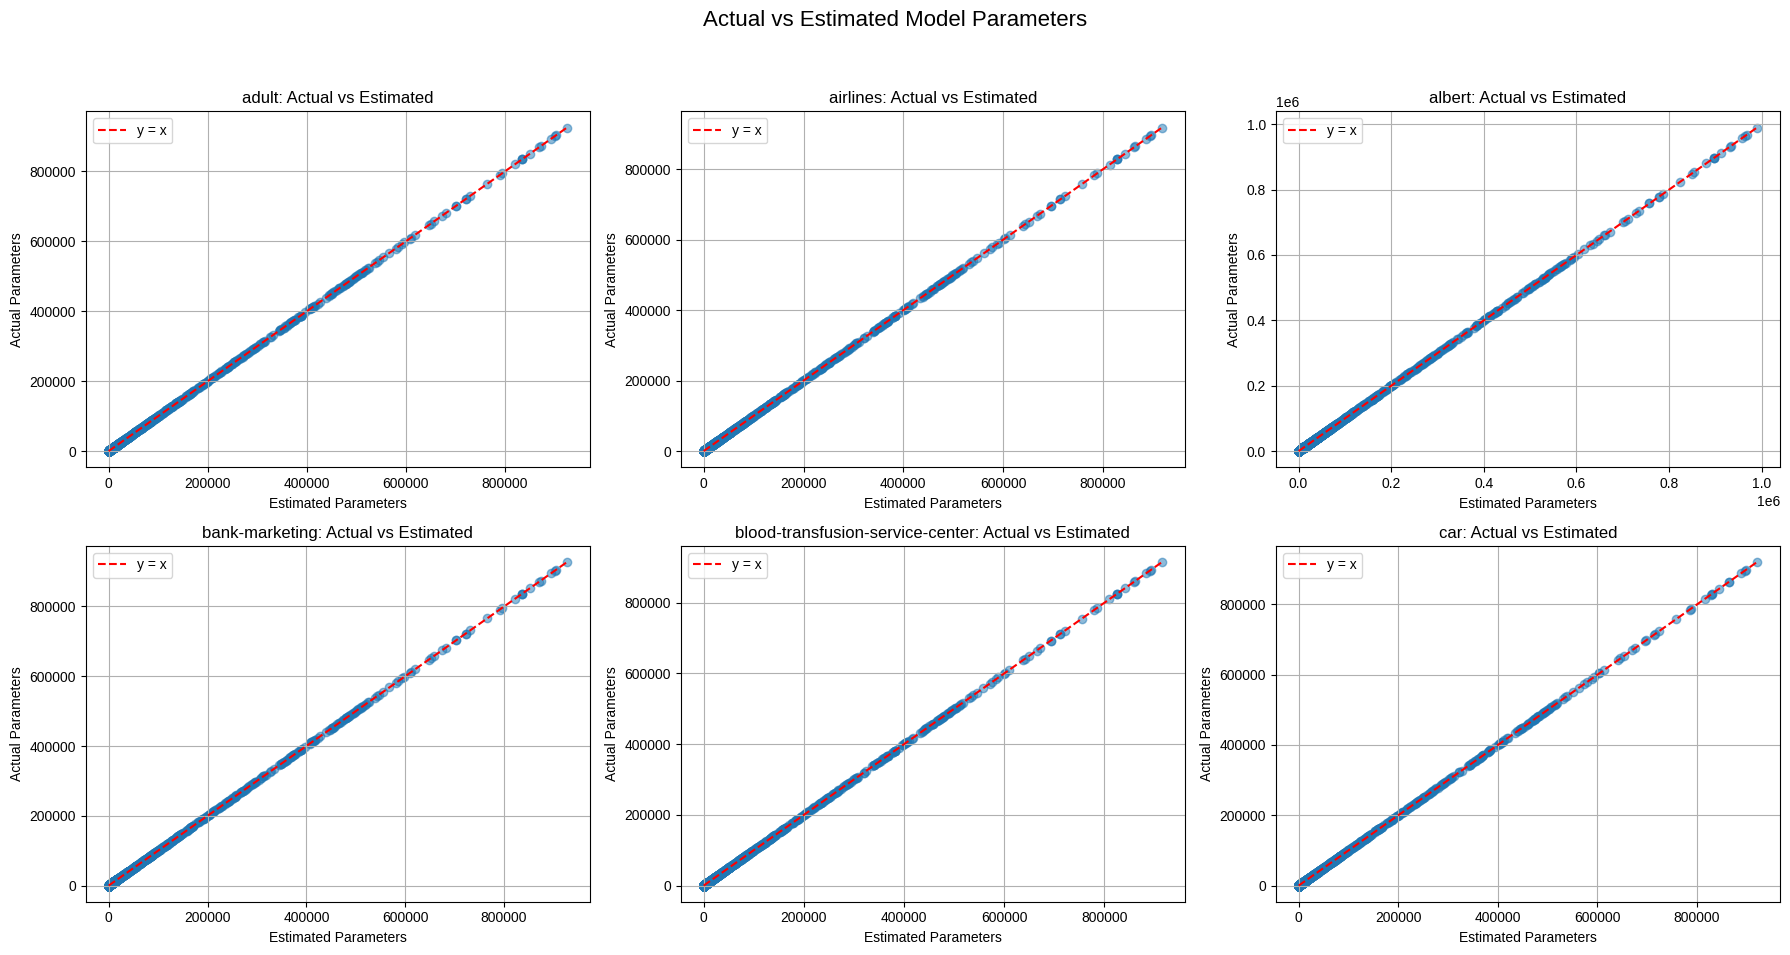

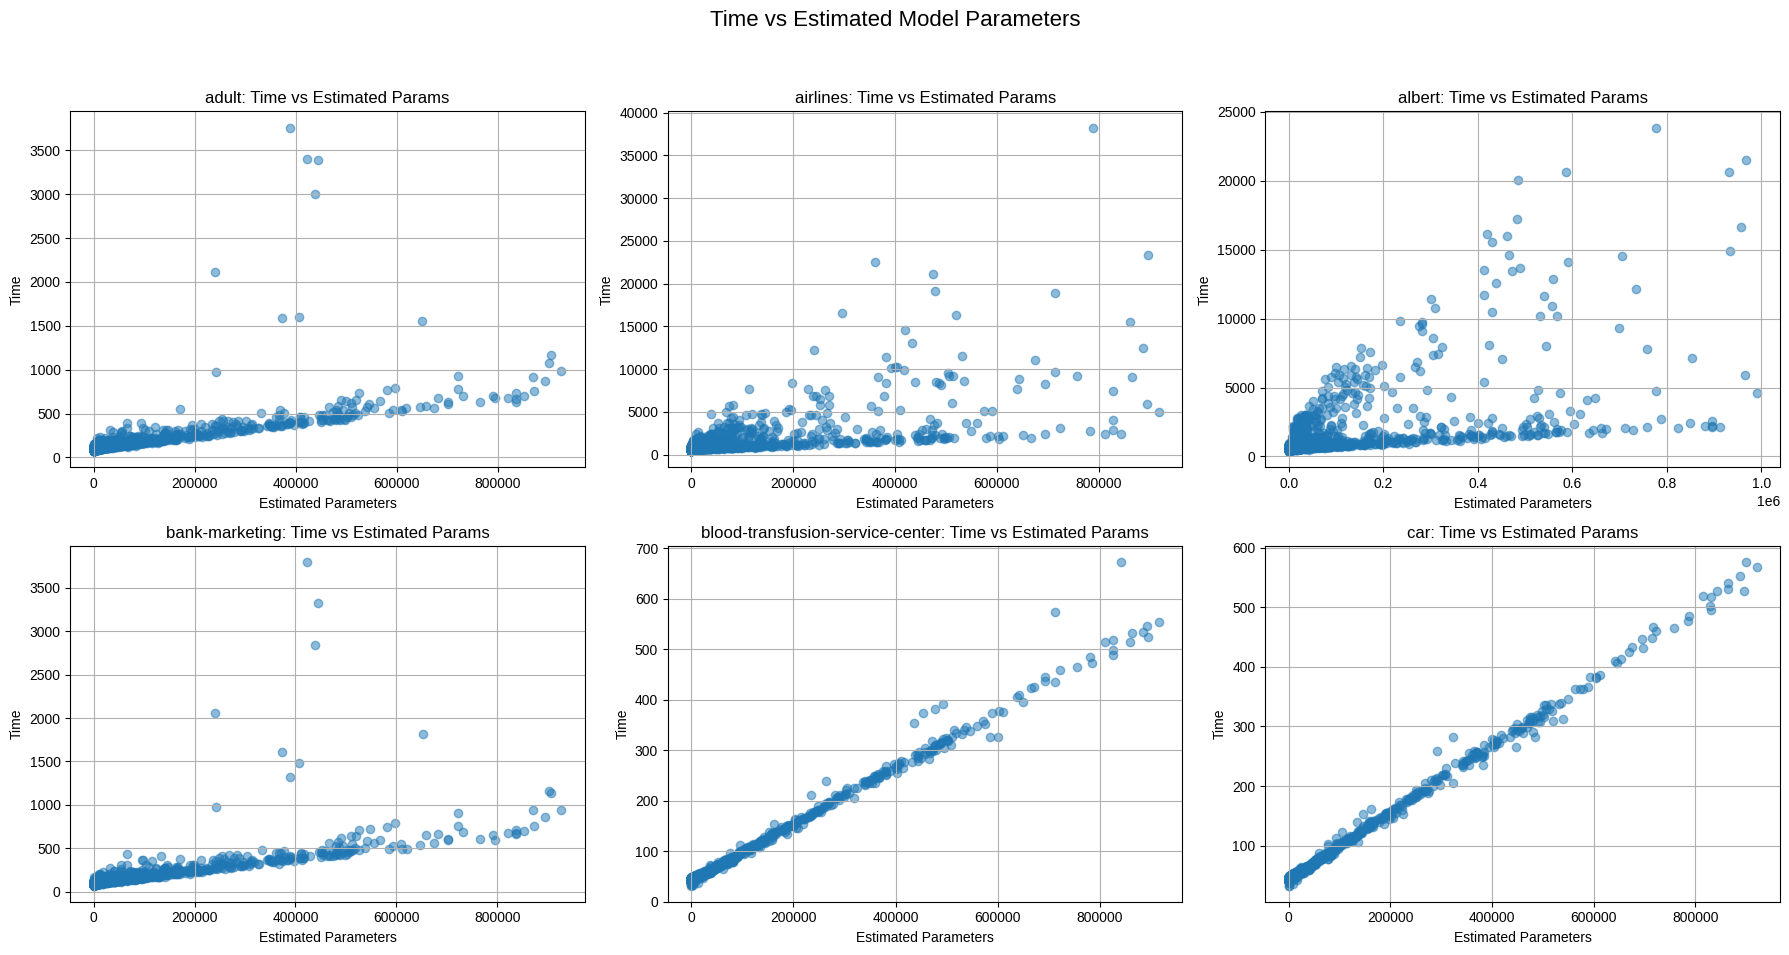

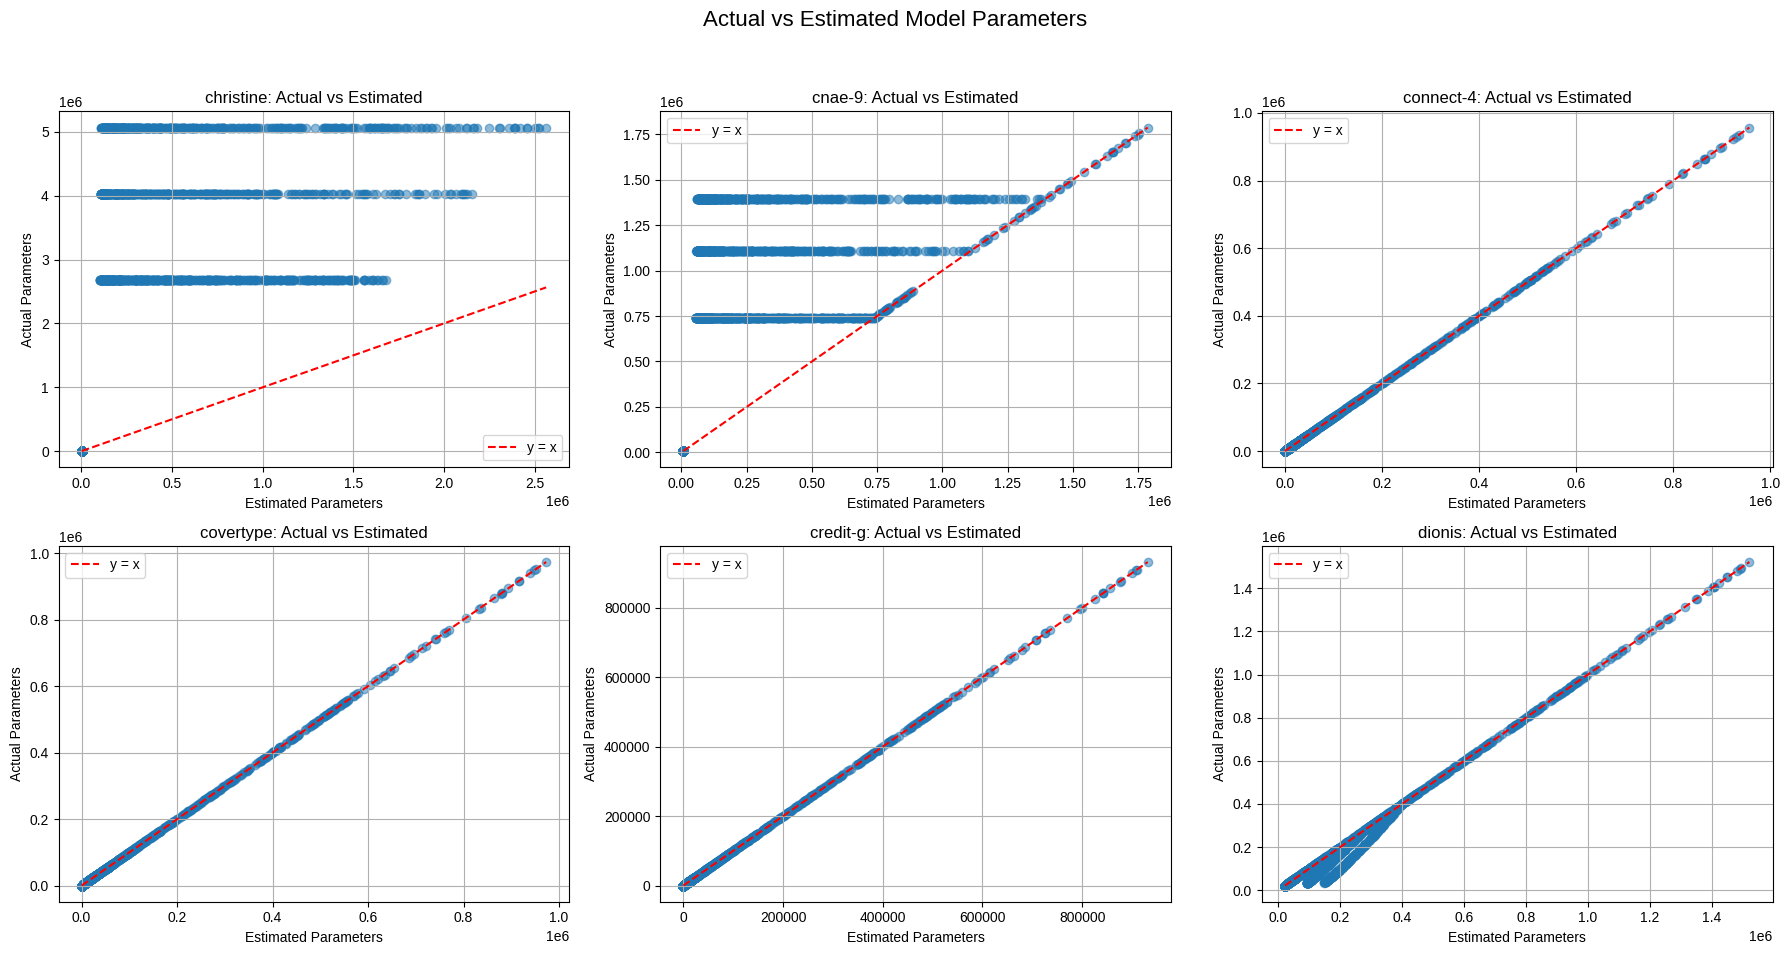

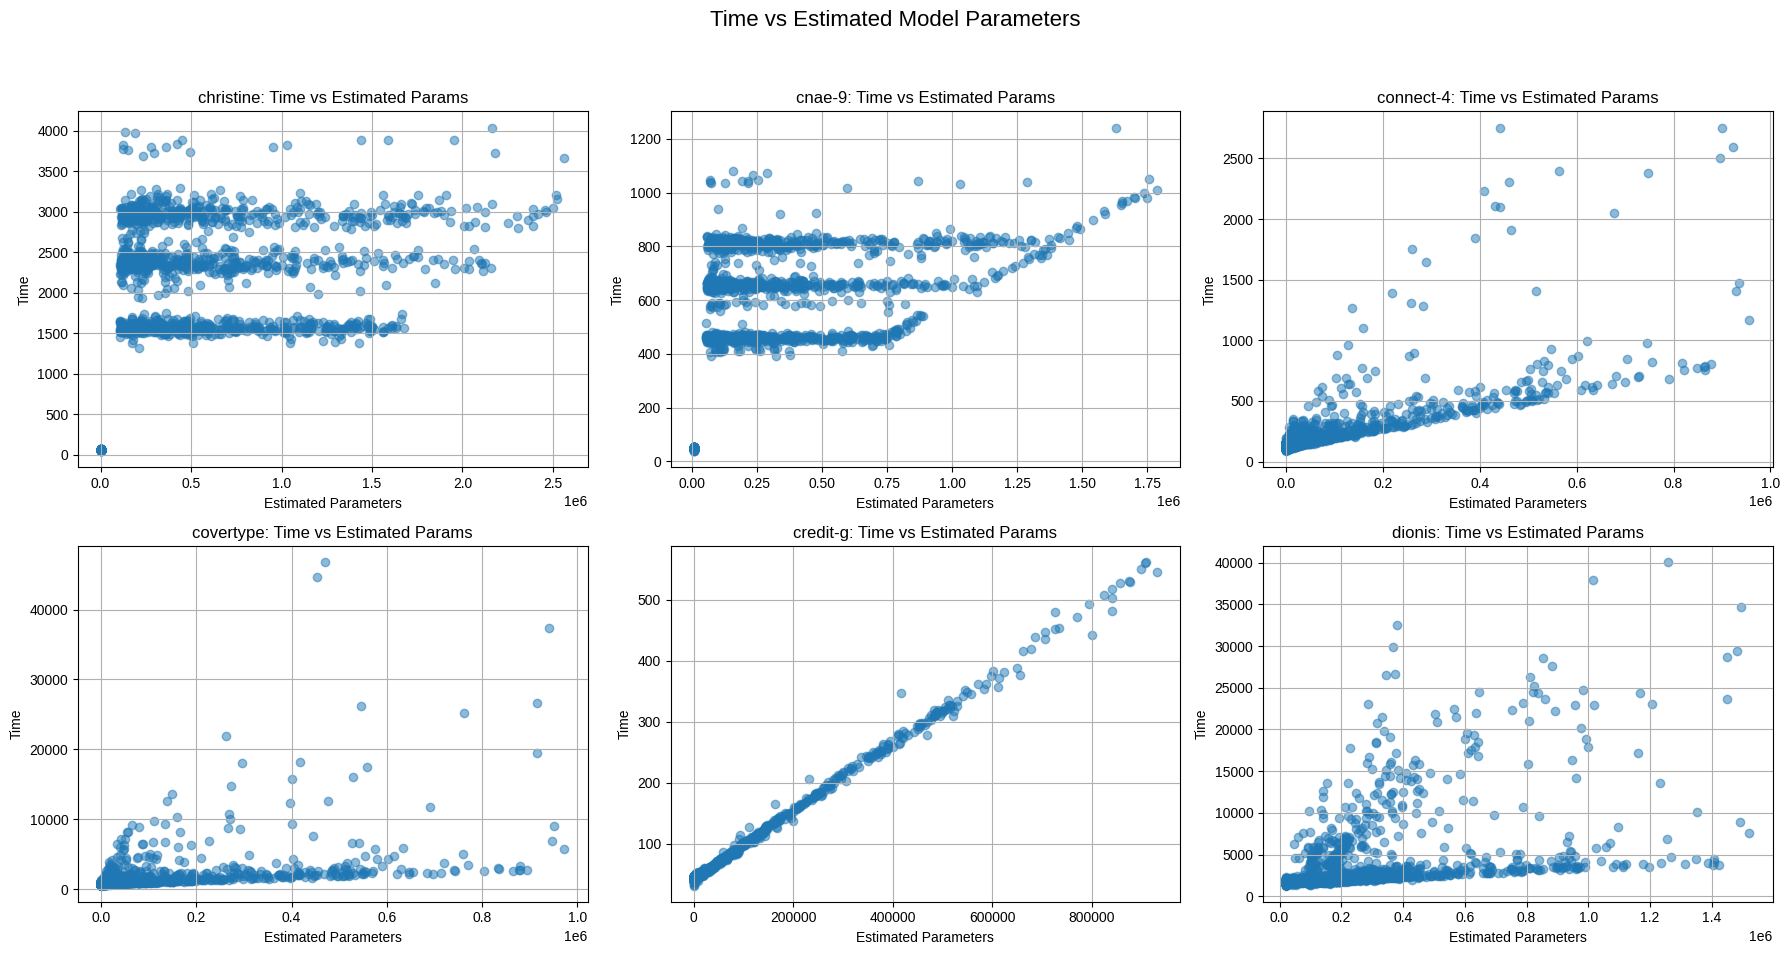

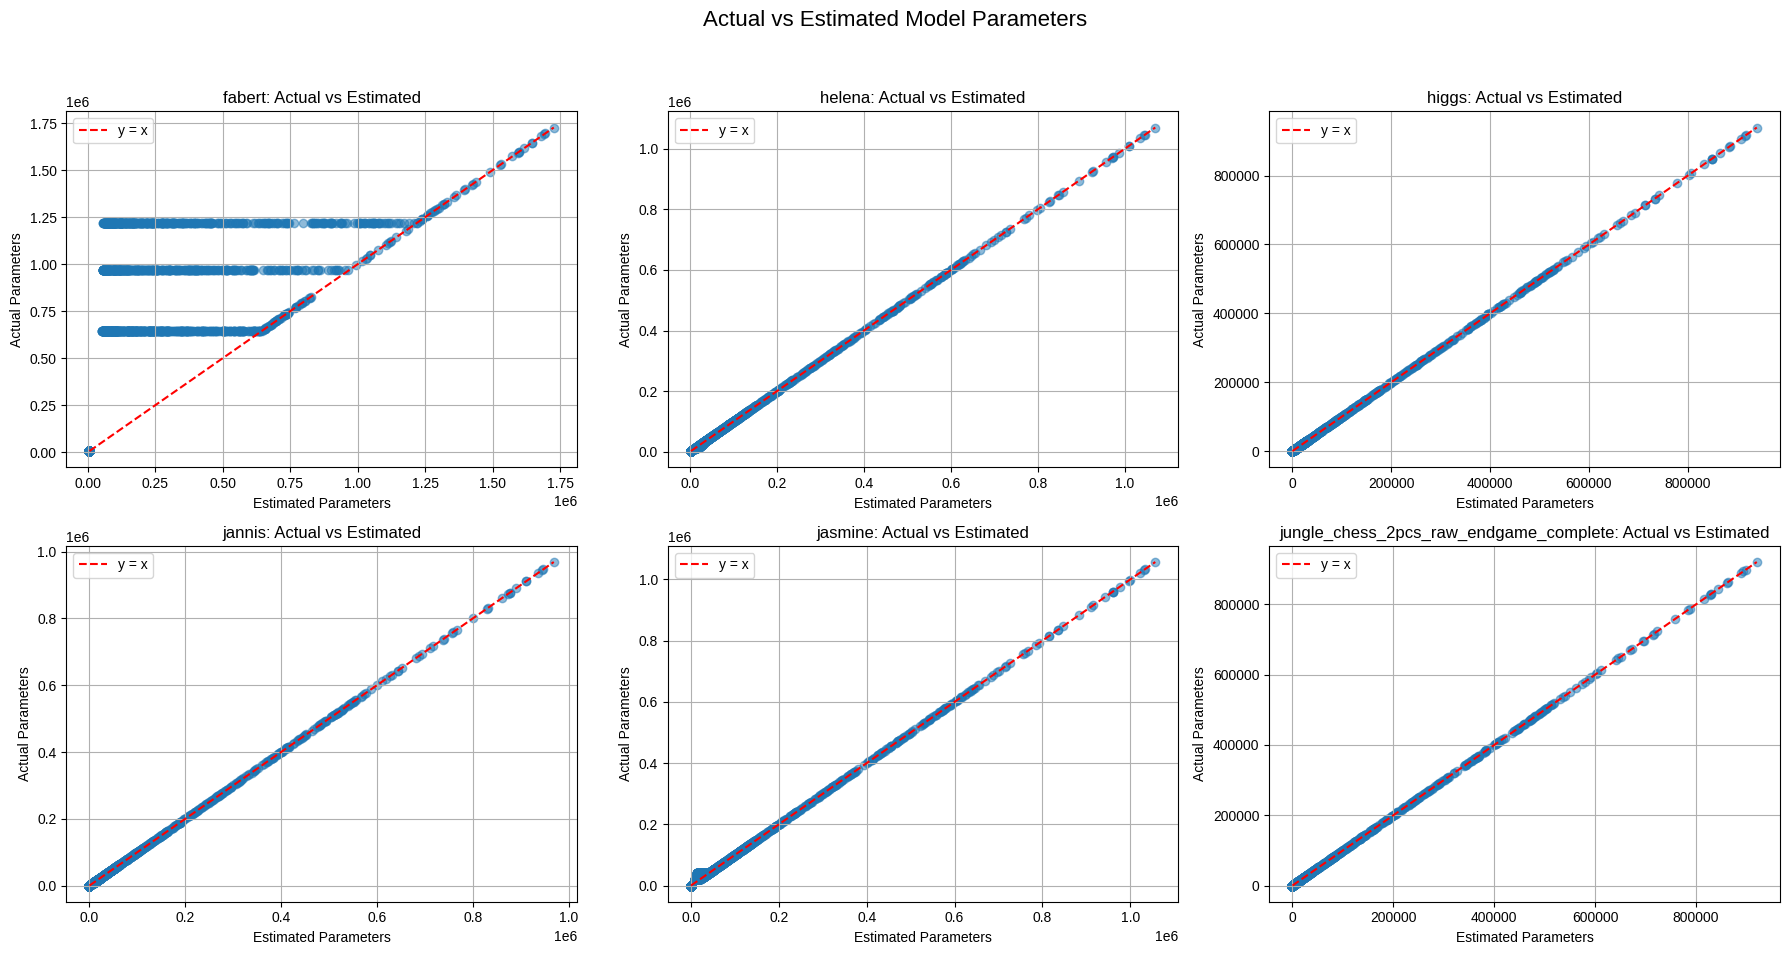

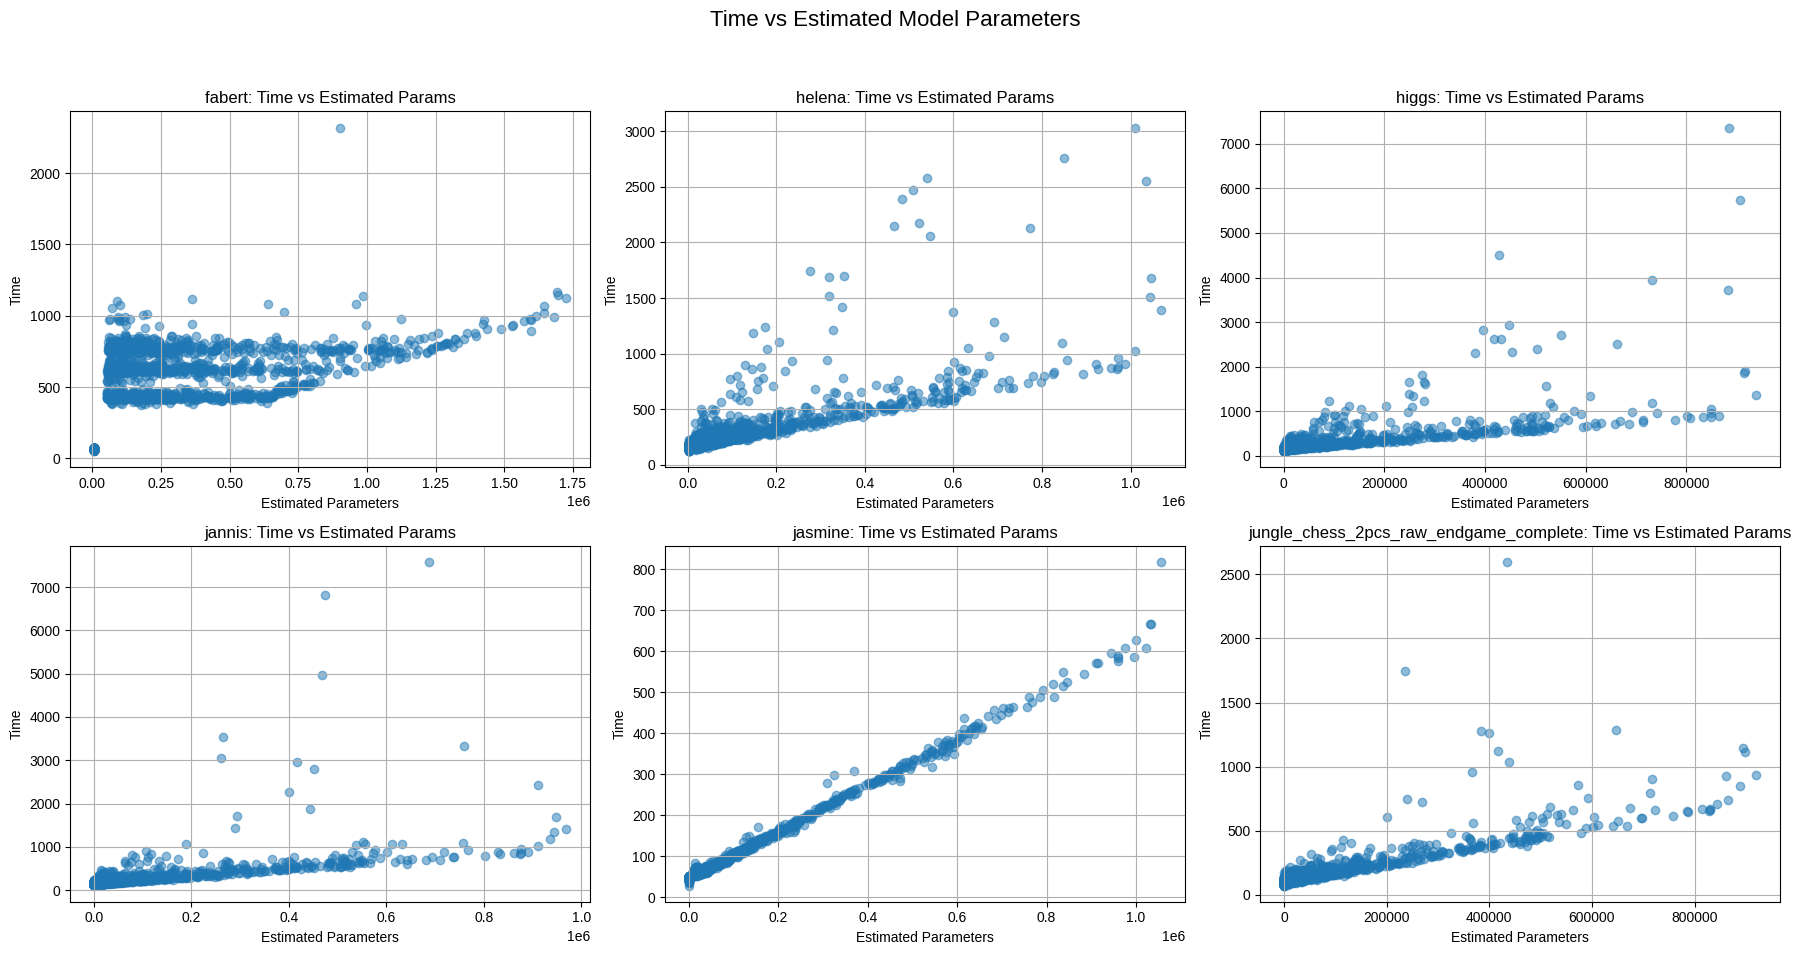

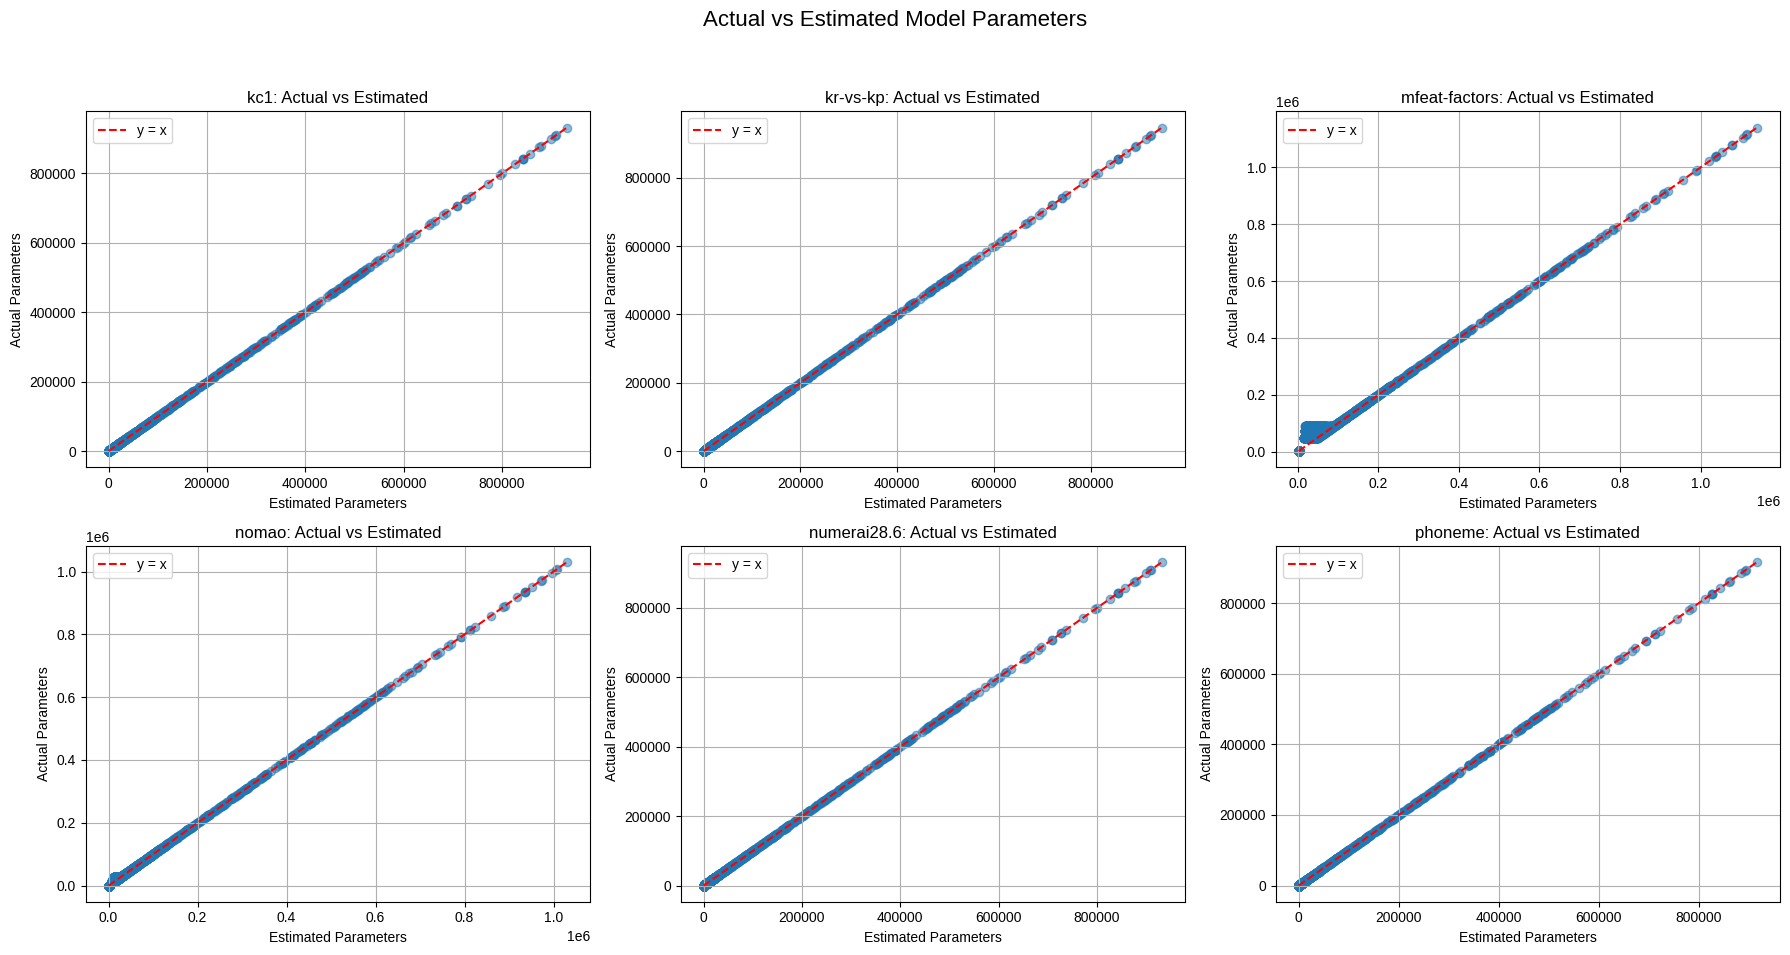

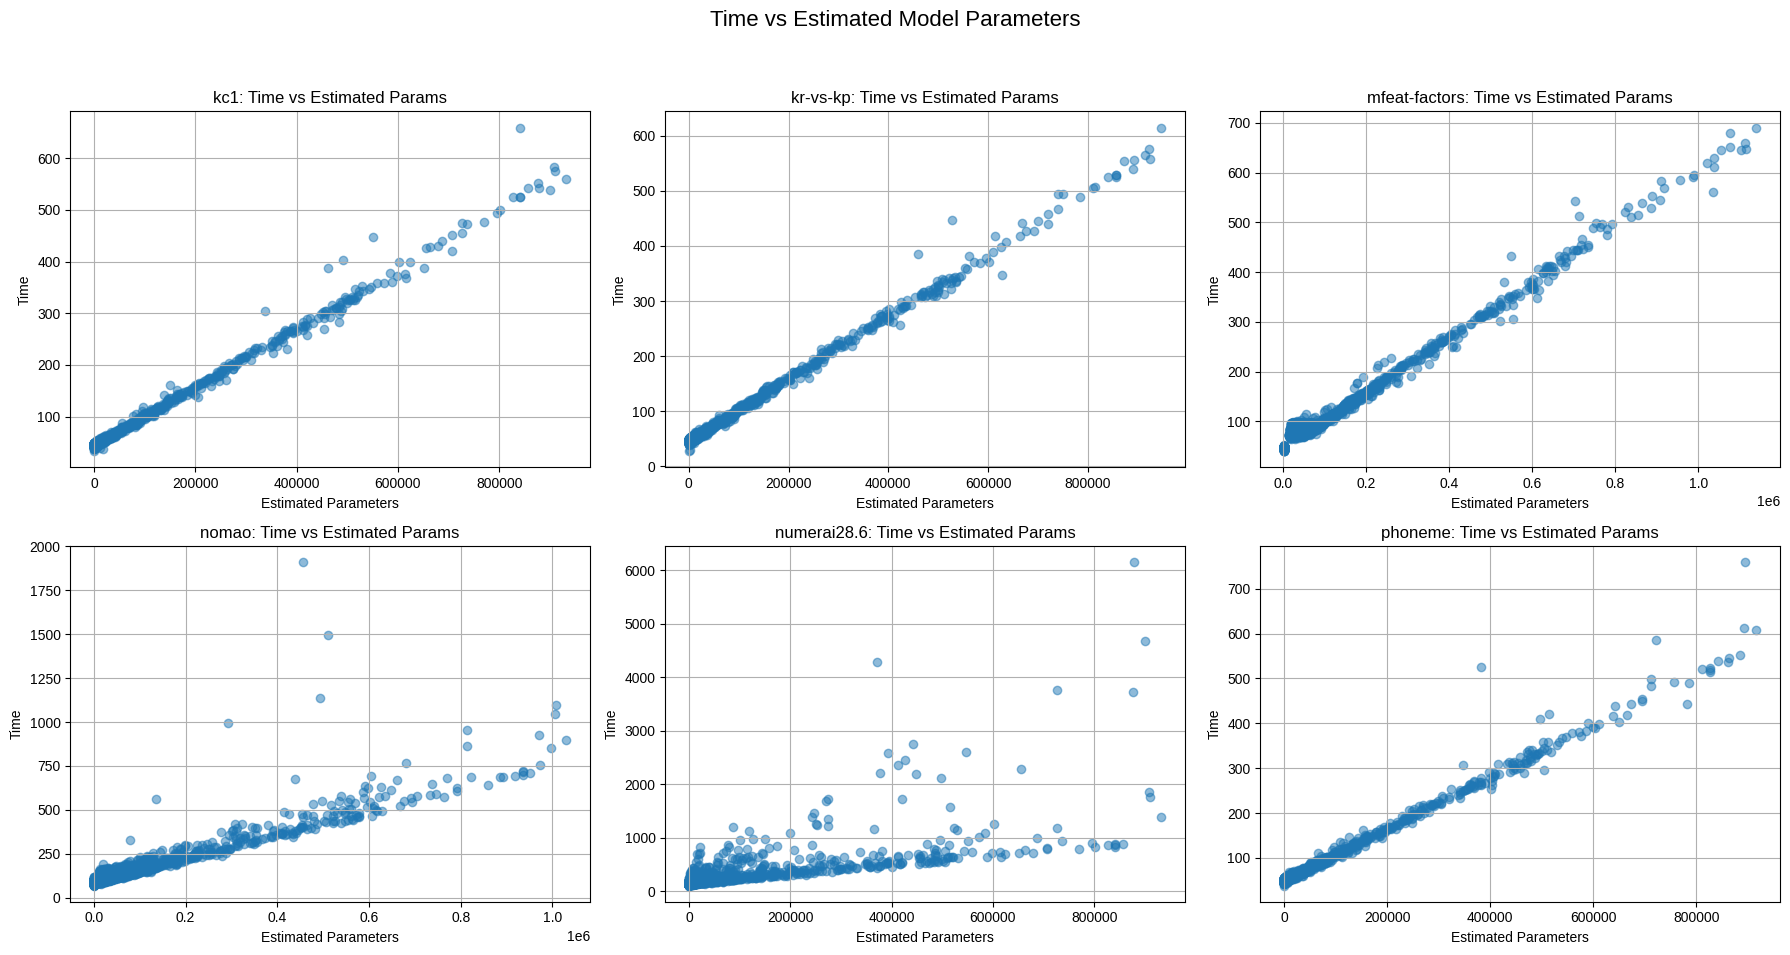

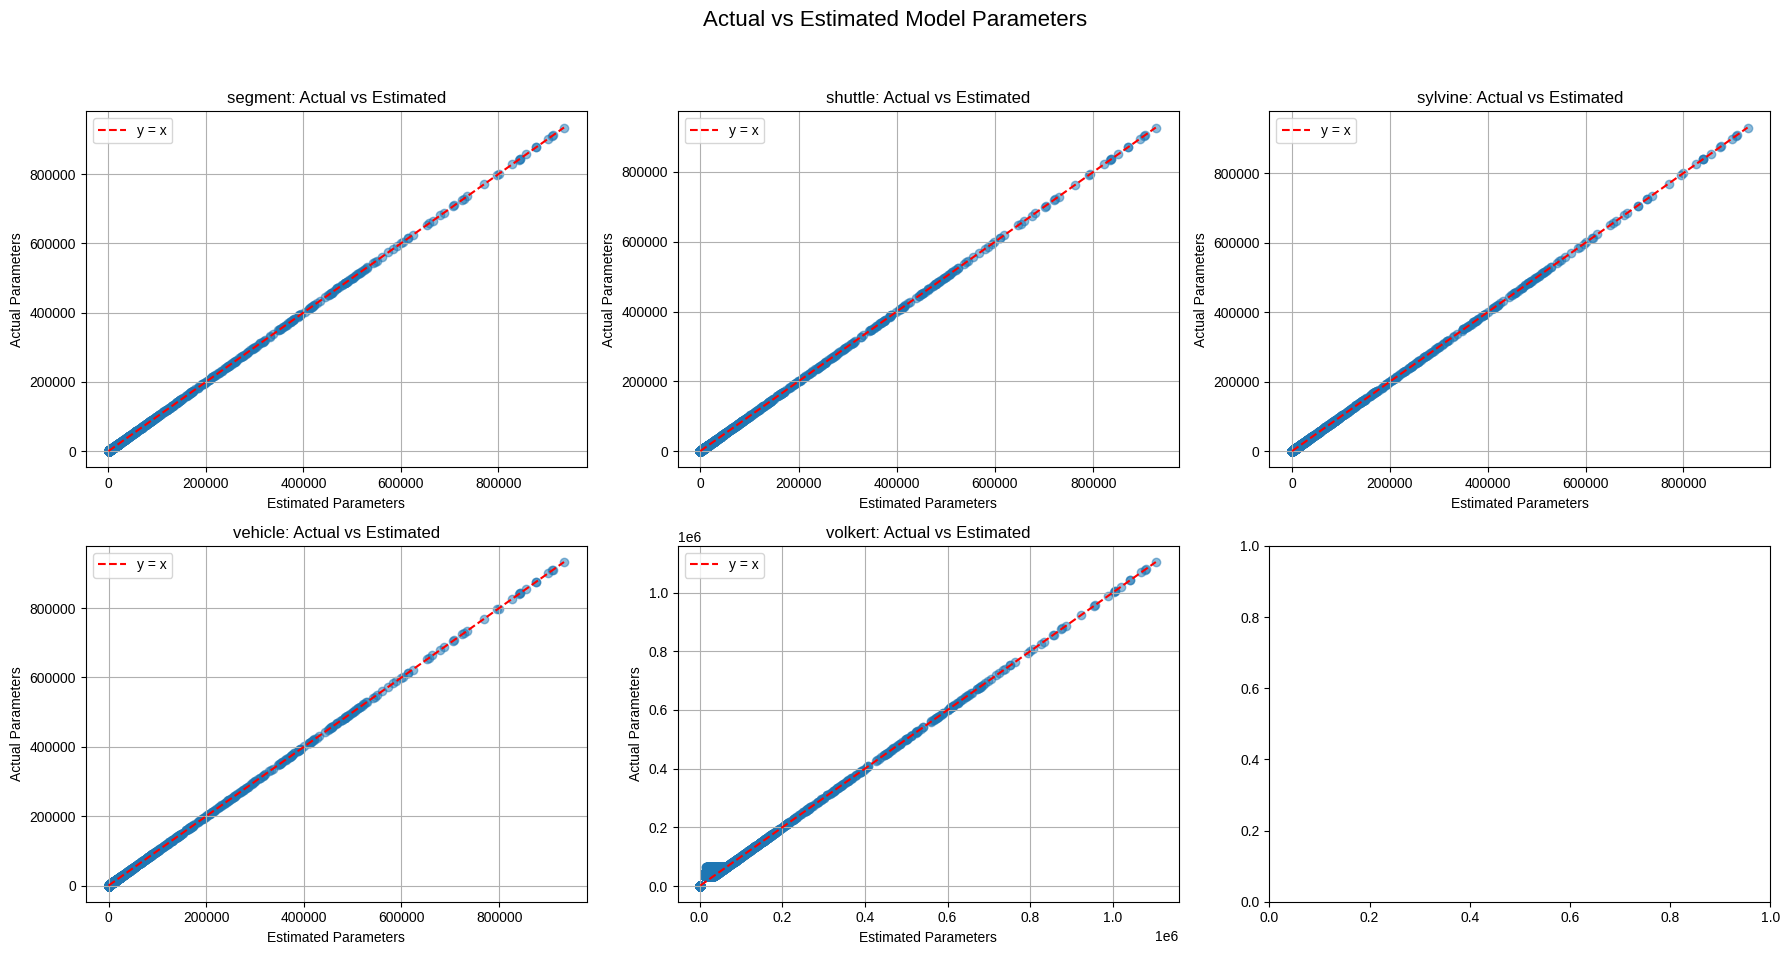

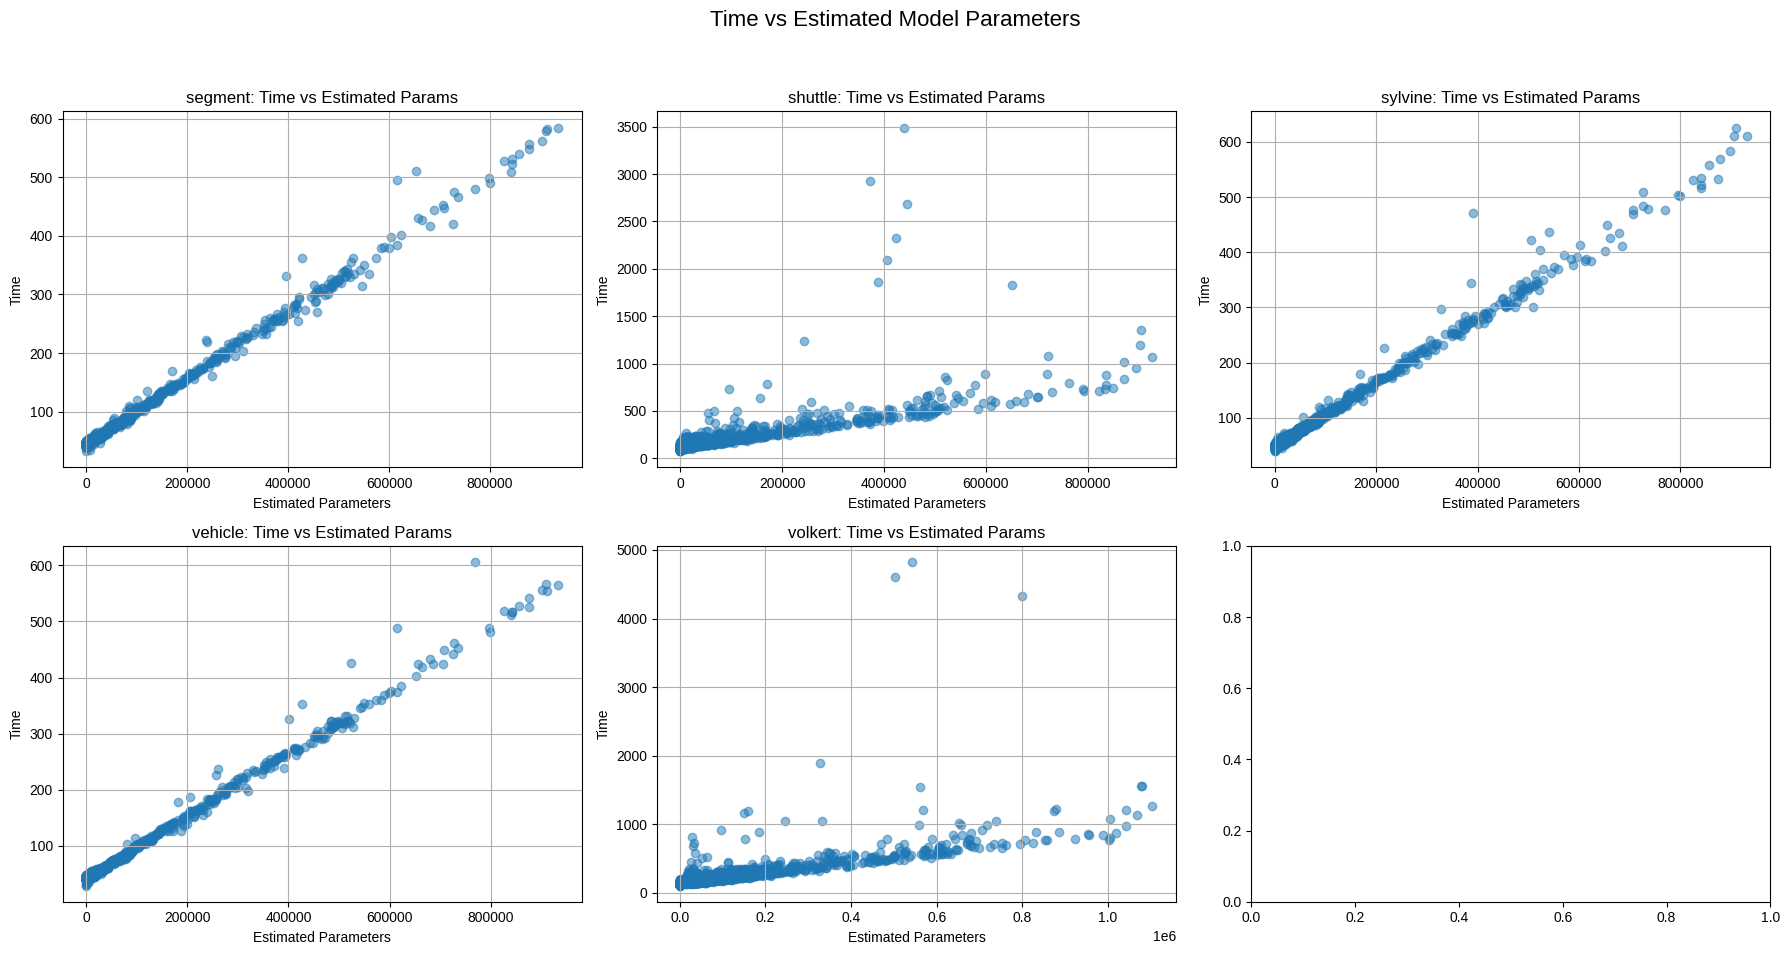

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import os 

dataset_names = ['APSFailure', 'Amazon_employee_access', 'Australian', 'Fashion-MNIST', 'KDDCup09_appetency', 'MiniBooNE', 'adult', 'airlines', 'albert', 'bank-marketing', 'blood-transfusion-service-center', 'car', 'christine', 'cnae-9', 'connect-4', 'covertype', 'credit-g', 'dionis', 'fabert', 'helena', 'higgs', 'jannis', 'jasmine', 'jungle_chess_2pcs_raw_endgame_complete', 'kc1', 'kr-vs-kp', 'mfeat-factors', 'nomao', 'numerai28.6', 'phoneme', 'segment', 'shuttle', 'sylvine', 'vehicle', 'volkert']

def estimate_model_parameters(input_dim, output_feat, max_units, num_layers):
    if num_layers == 1:
        return input_dim * output_feat + output_feat

    step_size = (max_units - output_feat) // (num_layers - 1)
    layer_sizes = [max_units - i * step_size for i in range(num_layers - 1)]
    layer_sizes.append(output_feat)

    total_params = 0
    prev = input_dim
    for width in layer_sizes:
        total_params += prev * width  # weights
        total_params += width         # biases
        prev = width
    return total_params

# Known dataset properties
dataset_info = {}
for dataset in dataset_names:
    dataset_info[dataset] = {}
    dataset_info[dataset]['input_dim'] = bench.query(dataset_name=dataset, tag="features", config_id=1999)
    dataset_info[dataset]['output_feat'] = bench.query(dataset_name=dataset, tag="classes", config_id=1999)


dataset_names = list(dataset_info.keys())
num_configs = 2000  # Adjust based on availability

num_plots = math.ceil(len(dataset_names) / 6)
for plot_idx in range(num_plots):
    # Setup subplots: 2 rows (actual vs est, and time vs est), 3 cols
    fig1, axes1 = plt.subplots(2, 3, figsize=(18, 10))
    fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))
    axes1 = axes1.flatten()
    axes2 = axes2.flatten()

    for i, (ax, dataset) in enumerate(zip(axes, dataset_names[plot_idx*6:(plot_idx+1)*6])):
        input_dim = dataset_info[dataset]['input_dim']
        output_feat = dataset_info[dataset]['output_feat']
        
        actual_params = []
        estimated_params = []
        times = []

        for config_id in range(num_configs):
            try:
                config = bench.query(dataset_name=dataset, tag="config", config_id=config_id)
                num_layers = int(config["num_layers"])
                max_units = int(config["max_units"])

                # Estimate parameters
                est = estimate_model_parameters(input_dim, output_feat, max_units, num_layers)

                # Get actual parameters and time
                actual = bench.query(dataset_name=dataset, tag="model_parameters", config_id=config_id)
                time_val = bench.query(dataset_name=dataset, tag="time", config_id=config_id)[-1]

                actual_params.append(actual)
                estimated_params.append(est)
                times.append(time_val)

            except Exception as e:
                print(f"Skipping config {config_id} for {dataset}: {e}")

        # Subplot 1: Actual vs Estimated model parameters
        ax1 = axes1[i]
        ax1.scatter(estimated_params, actual_params, alpha=0.5)
        ax1.plot([min(estimated_params), max(estimated_params)],
                [min(estimated_params), max(estimated_params)], color='red', linestyle='--', label="y = x")
        ax1.set_xlabel("Estimated Parameters")
        ax1.set_ylabel("Actual Parameters")
        ax1.set_title(f"{dataset}: Actual vs Estimated")
        ax1.grid(True)
        ax1.legend()

        # Subplot 2: Time vs Estimated Parameters
        ax2 = axes2[i]
        ax2.scatter(estimated_params, times, alpha=0.5)
        ax2.set_xlabel("Estimated Parameters")
        ax2.set_ylabel("Time")
        ax2.set_title(f"{dataset}: Time vs Estimated Params")
        ax2.grid(True)

        fig1.suptitle("Actual vs Estimated Model Parameters", fontsize=16)
        fig2.suptitle("Time vs Estimated Model Parameters", fontsize=16)
        fig1.tight_layout(rect=[0, 0.03, 1, 0.95])
        fig2.tight_layout(rect=[0, 0.03, 1, 0.95])
        os.makedirs("../plots/lcbench_full_actual_vs_estimated_model_params", exist_ok=True)
        os.makedirs("../plots/lcbench_full_time_vs_estimated_model_params", exist_ok=True)
        fig1.savefig(f"../plots/lcbench_full_actual_vs_estimated_model_params/actual_vs_estimated_model_params_{plot_idx}.pdf")
        fig2.savefig(f"../plots/lcbench_full_actual_vs_estimated_model_params/time_vs_estimated_model_params_{plot_idx}.pdf")